In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr
import gsw

In [2]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

emulator_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-03-26-eval:samudra_llc:epoch1_oct2012_patchloc=i(2880,3600)-j(720,1440)/predictions_4d.zarr'
emulator_patch_full = xr.open_dataset(emulator_path, consolidated=True)
#emulator_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [3]:
#9216,9960

In [17]:
extent = 3
llc_patch = llc_patch_full.isel(time=slice(9216, 9216 + extent))
emulator_patch = emulator_patch_full.isel(time=slice(0, extent))#(9216, 9216 + extent))#(0, extent))

## Shear

In [6]:
# LLC Patch
dz_llc = np.diff(llc_patch.Z.values)
dz_llc = dz_llc[np.newaxis, :, np.newaxis, np.newaxis]

du_dz_llc = np.diff(llc_patch['U'].values, axis=1) / dz_llc
dv_dz_llc = np.diff(llc_patch['V'].values, axis=1) / dz_llc

S2_llc = du_dz_llc**2 + dv_dz_llc**2

llc_patch['S2'] = xr.DataArray(S2_llc, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': llc_patch['time'], 'k': llc_patch['k'][:-1],
                                        'j': llc_patch['j'], 'i': llc_patch['i']})

In [7]:
# Emulator Patch
dz_emulator = np.diff(emulator_patch.Z.values)
dz_emulator = dz_emulator[np.newaxis, :, np.newaxis, np.newaxis]

du_dz_emulator = np.diff(emulator_patch['U'].values, axis=1) / dz_emulator
dv_dz_emulator = np.diff(emulator_patch['V'].values, axis=1) / dz_emulator

S2_emulator = du_dz_emulator**2 + dv_dz_emulator**2

emulator_patch['S2'] = xr.DataArray(S2_emulator, dims=['time', 'k', 'j', 'i'], 
                                    coords={'time': emulator_patch['time'], 'k': emulator_patch['k'][:-1],
                                            'j': emulator_patch['j'], 'i': emulator_patch['i']})

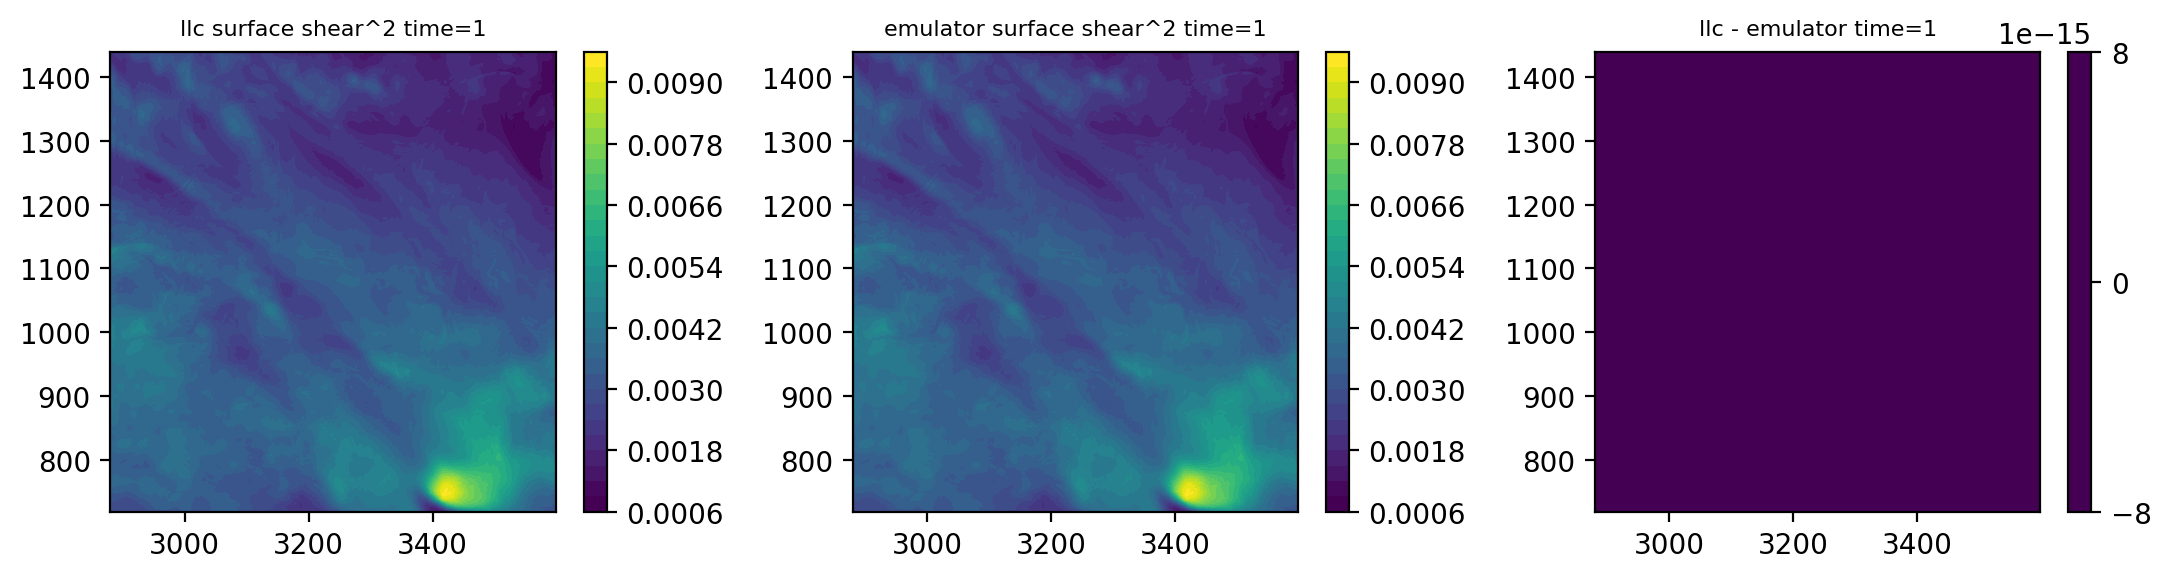

In [8]:
llc_vis = llc_patch.isel(time=1,k=0).S2
emulator_vis = emulator_patch.isel(time=1,k=0).S2

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="viridis",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface shear^2 time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="viridis",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface shear^2 time=1', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="viridis",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
S2_hist_llc = llc_patch.S2.stack(vals=['time','i','j']).values[:-1]
S2_hist_emulator = emulator_patch.S2.stack(vals=['time','i','j']).values[:-1]

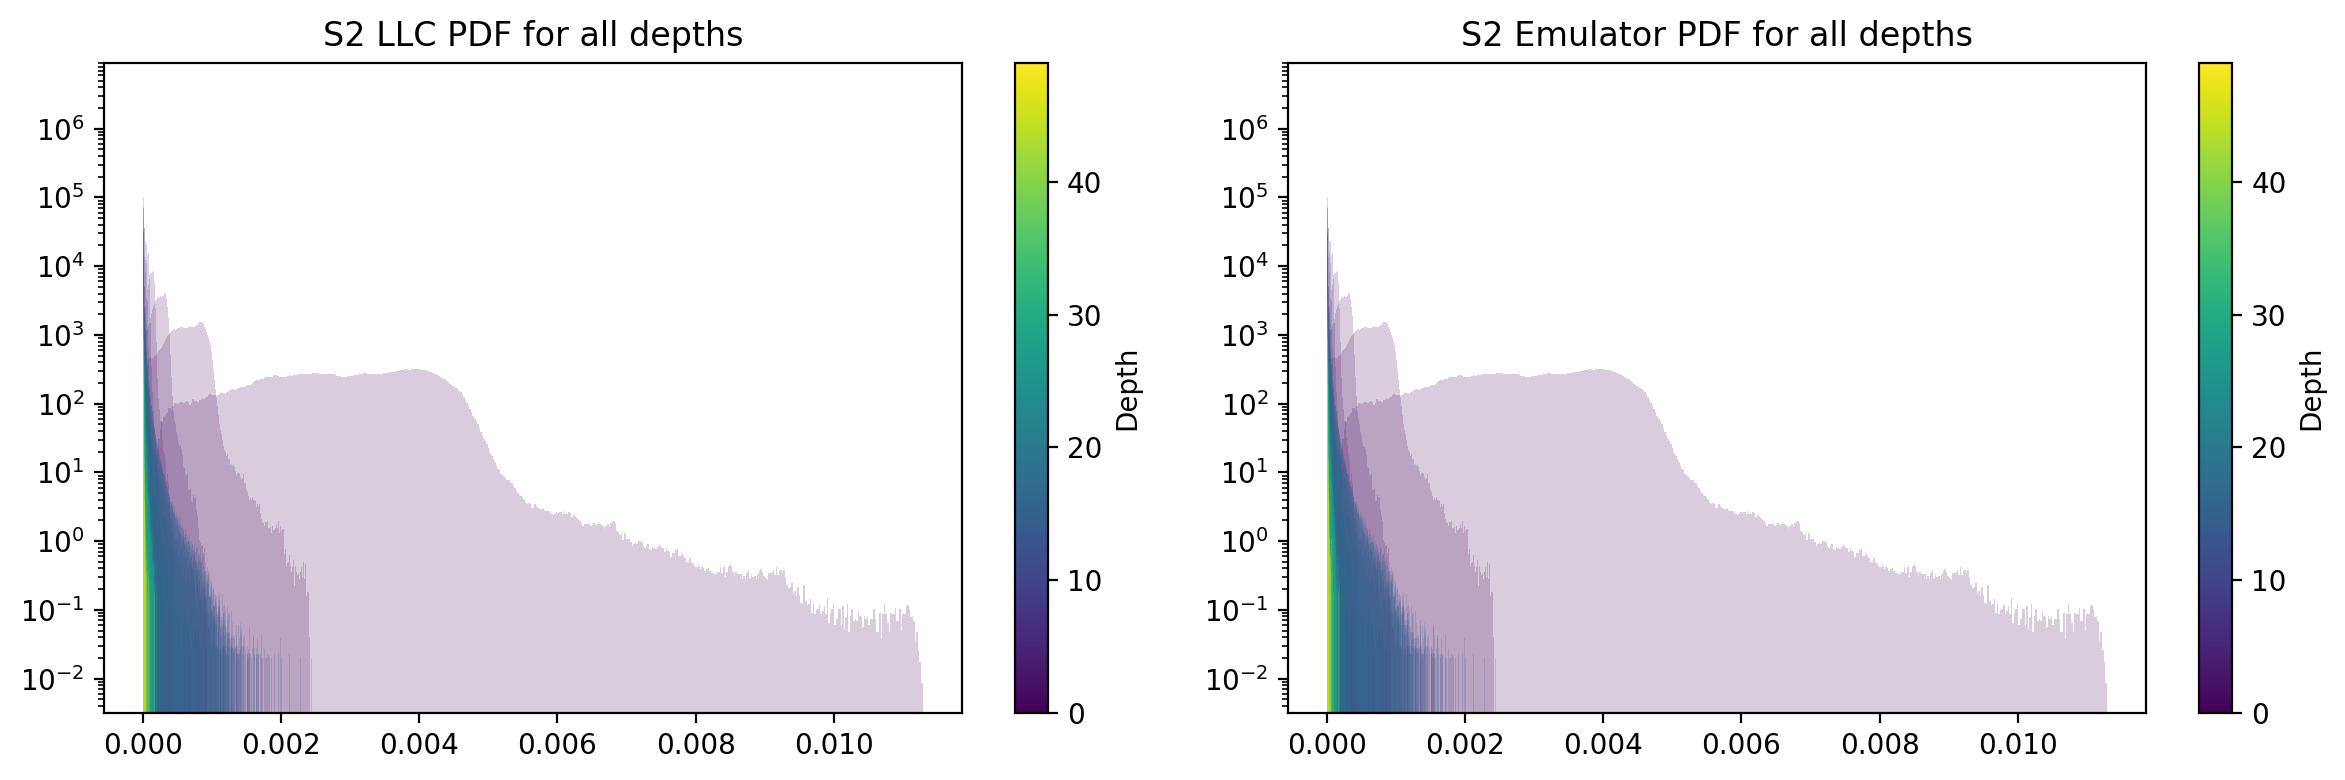

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

cm = [plt.cm.viridis(i/len(S2_hist_llc)) for i in range(len(S2_hist_llc))]
for k in range(0,len(S2_hist_llc)):
    ax1.hist(S2_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(S2_hist_llc)-1))
sm.set_array([])
ax1.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('S2 LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(S2_hist_emulator)) for i in range(len(S2_hist_emulator))]
for k in range(0,len(S2_hist_emulator)):
    ax2.hist(S2_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(S2_hist_emulator)-1))
sm.set_array([])
ax2.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('S2 Emulator PDF for all depths')
plt.tight_layout()
plt.show()

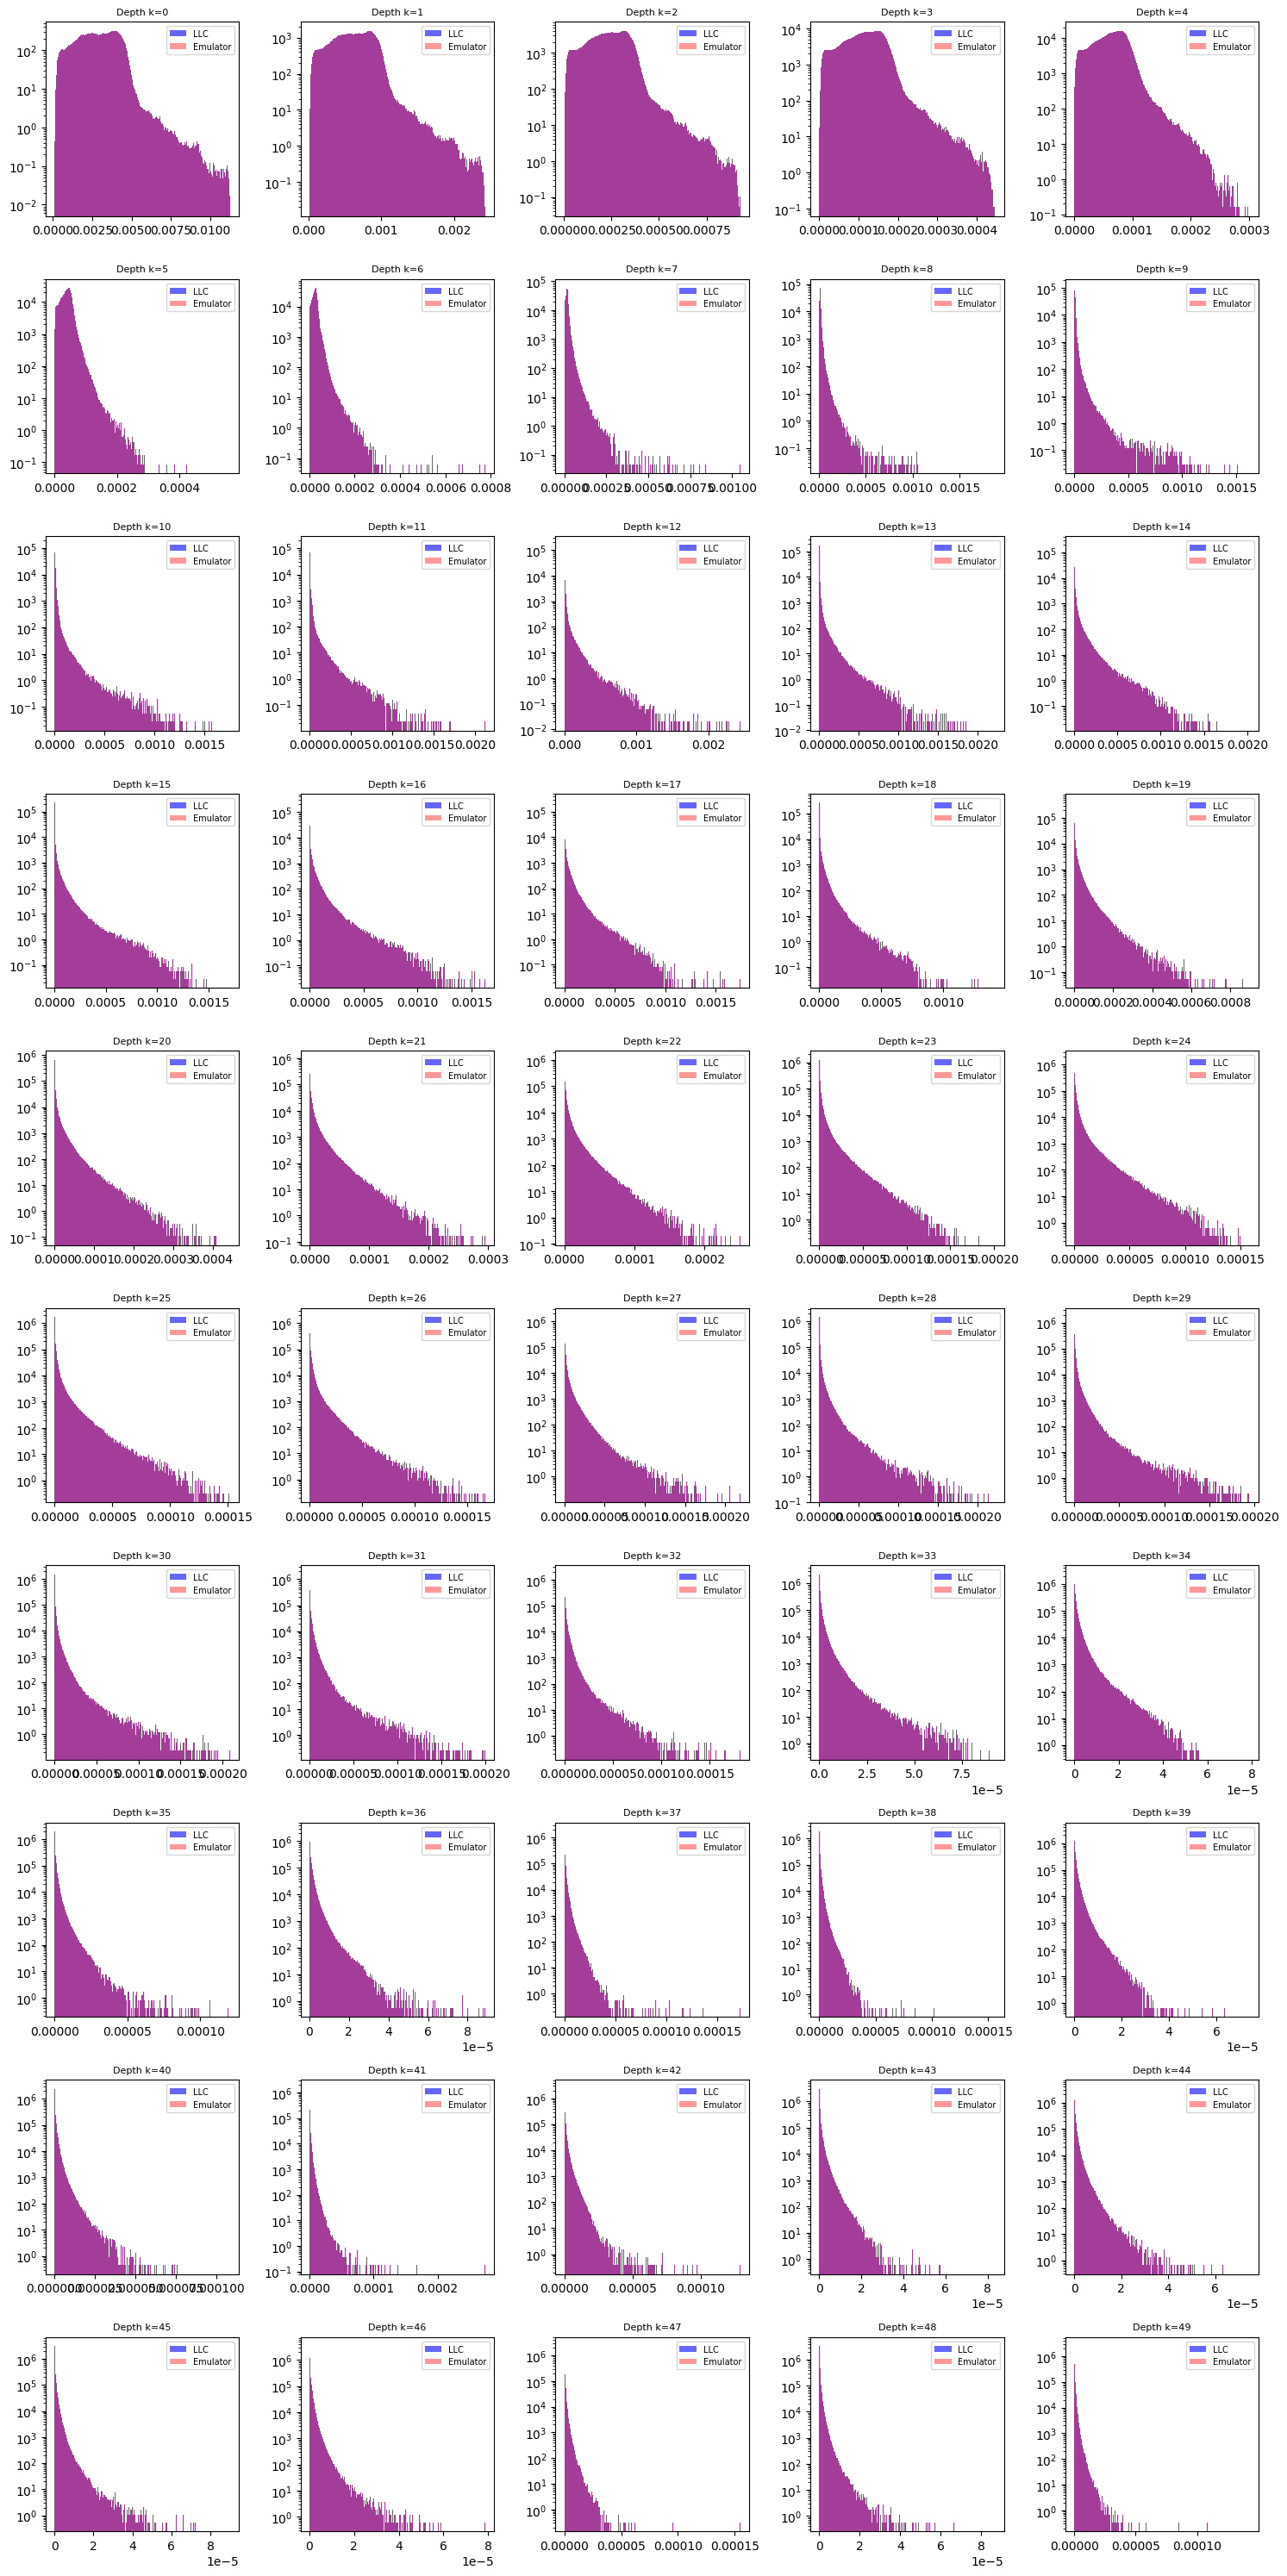

In [ ]:
n_depths = len(S2_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(S2_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(S2_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.set_yscale('log')
    ax.legend(fontsize=7)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

## Vorticity

In [21]:
omega = 7.2921e-5

# LLC Patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

vort_llc = ((np.roll(llc_patch['V'].values, -1, axis=3) - np.roll(llc_patch['V'].values, 1, axis=3)) / 2 - \
            (np.roll(llc_patch['U'].values, -1, axis=2) - np.roll(llc_patch['U'].values, 1, axis=2)) / 2)

vort_llc_normalized = vort_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
vort_llc_normalized = np.clip(vort_llc_normalized, np.nanpercentile(vort_llc_normalized, 1), np.nanpercentile(vort_llc_normalized, 99))
vort_llc_normalized = vort_llc_normalized / np.nanmax(np.abs(vort_llc_normalized))

llc_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_llc_normalized)

# Emulator Patch
f_0_emulator = np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

vort_emulator = ((np.roll(emulator_patch['V'].values, -1, axis=3) - np.roll(emulator_patch['V'].values, 1, axis=3)) / 2 - \
                 (np.roll(emulator_patch['U'].values, -1, axis=2) - np.roll(emulator_patch['U'].values, 1, axis=2)) / 2)

vort_emulator_normalized = vort_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]
vort_emulator_normalized = np.clip(vort_emulator_normalized, np.nanpercentile(vort_emulator_normalized, 1), np.nanpercentile(vort_emulator_normalized, 99))
vort_emulator_normalized = vort_emulator_normalized / np.nanmax(np.abs(vort_emulator_normalized))

emulator_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_emulator_normalized)

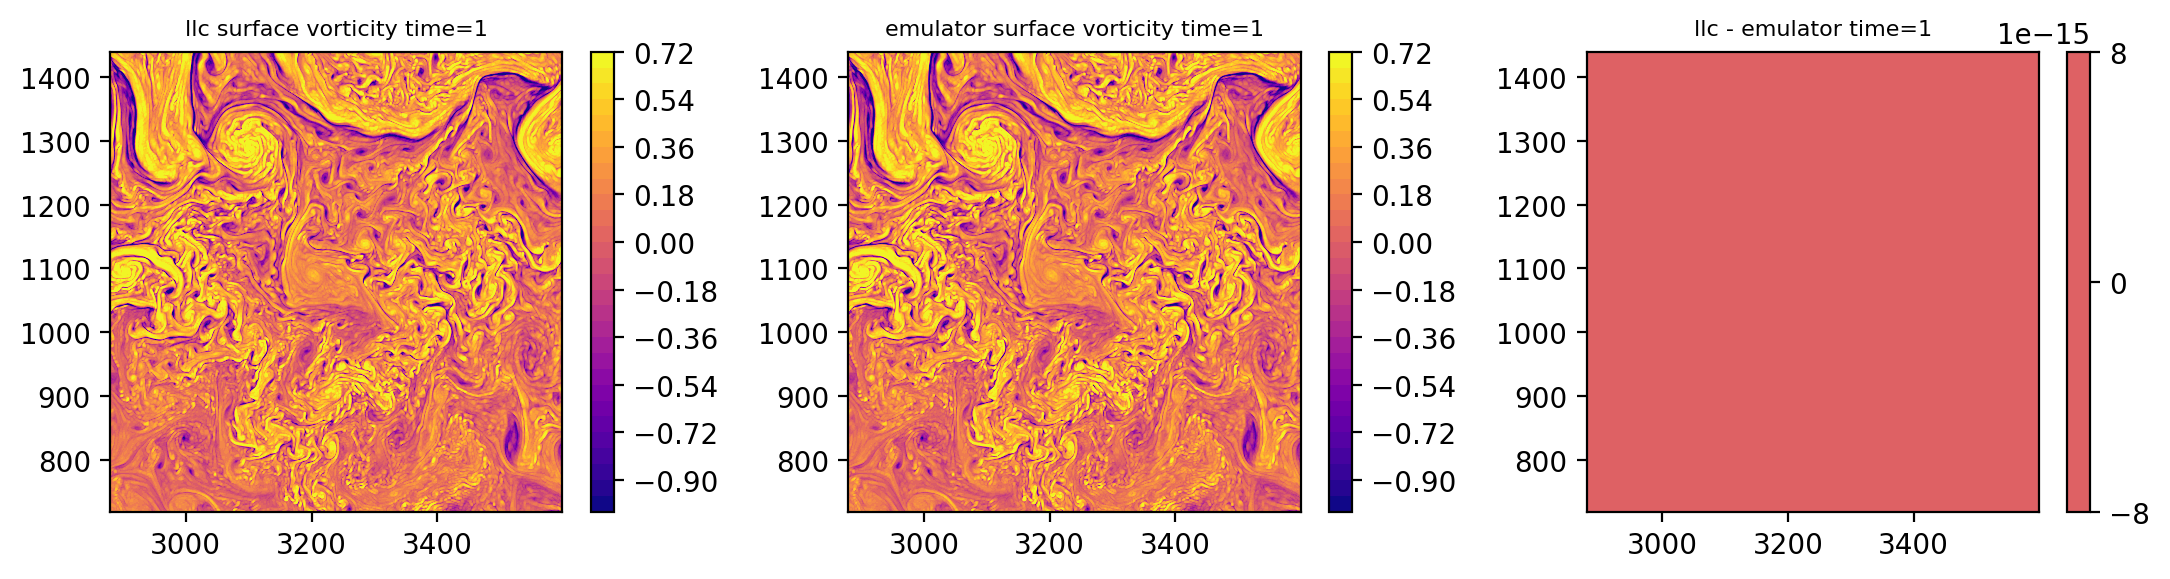

In [22]:
llc_vis = llc_patch.isel(time=1,k=0).vorticity
emulator_vis = emulator_patch.isel(time=1,k=0).vorticity

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="plasma",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface vorticity time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="plasma",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface vorticity time=1', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="plasma",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
vort_hist_llc = llc_patch.vorticity.stack(vals=['time','i','j']).values
vort_hist_emulator = emulator_patch.vorticity.stack(vals=['time','i','j']).values

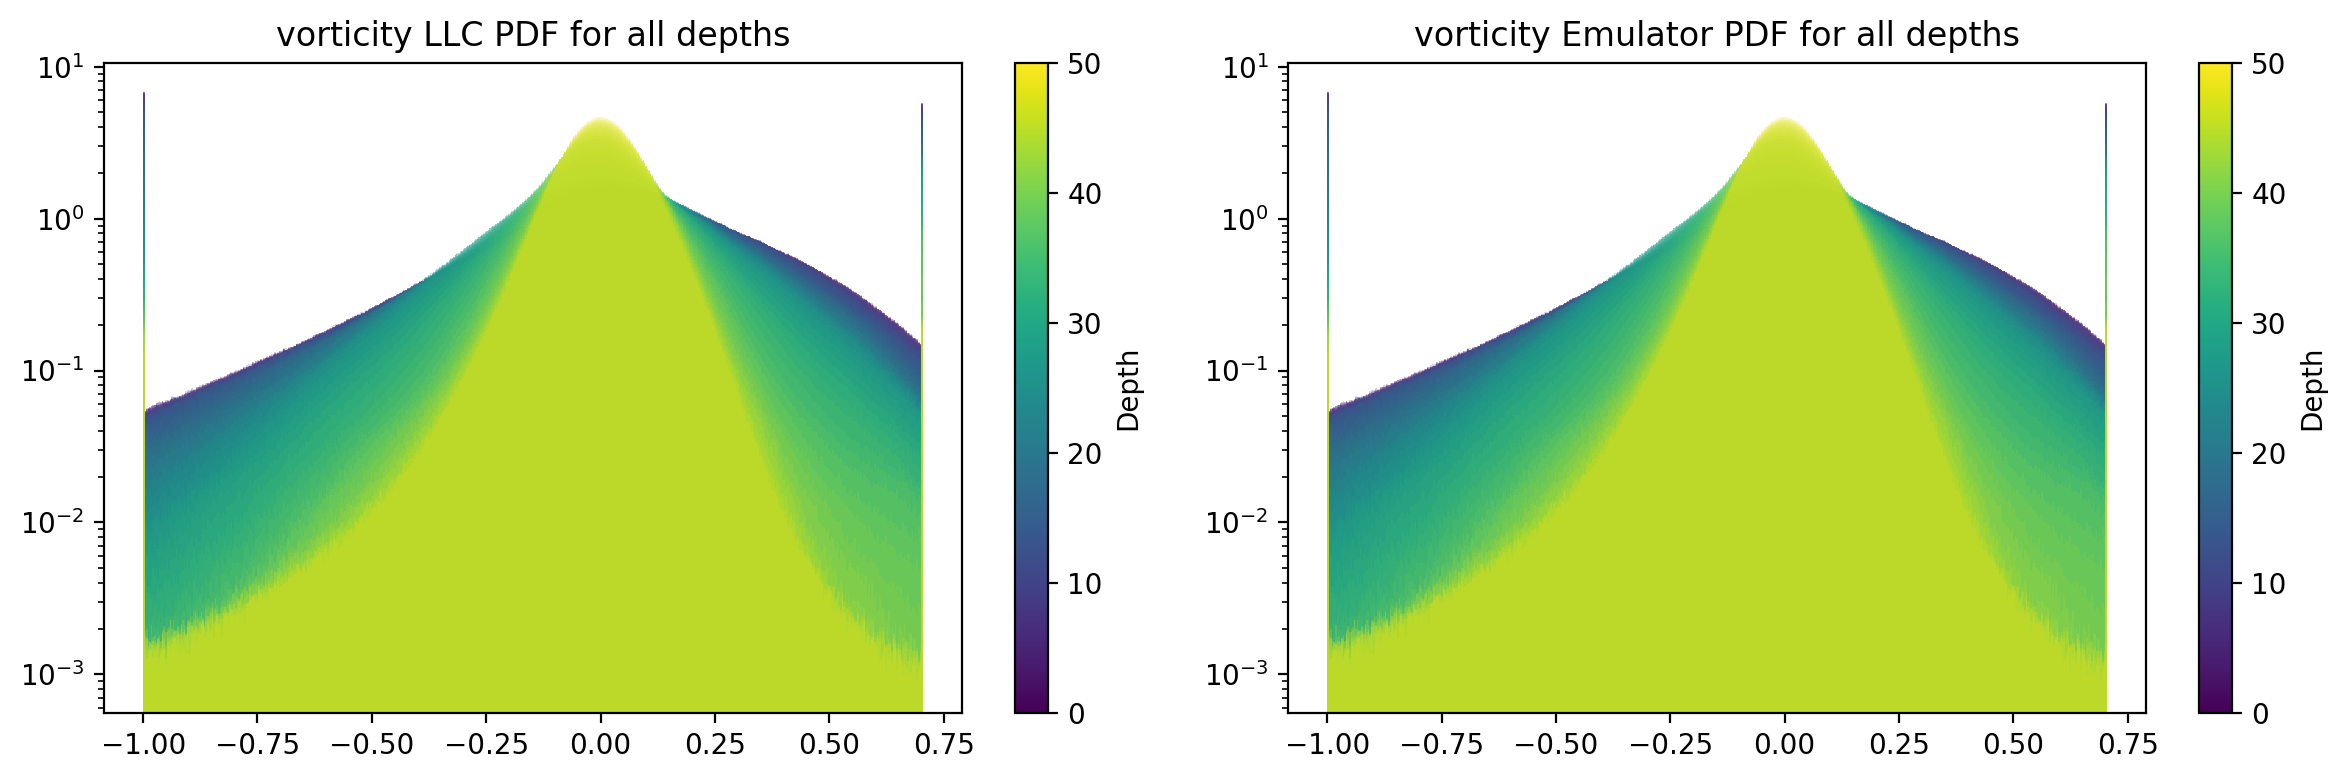

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

cm = [plt.cm.viridis(i/len(vort_hist_llc)) for i in range(len(vort_hist_llc))]
for k in range(0,len(vort_hist_llc)):
    ax1.hist(vort_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(vort_hist_llc)-1))
sm.set_array([])
ax1.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('vorticity LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(vort_hist_emulator)) for i in range(len(vort_hist_emulator))]
for k in range(0,len(vort_hist_emulator)):
    ax2.hist(vort_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(vort_hist_emulator)-1))
sm.set_array([])
ax2.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('vorticity Emulator PDF for all depths')
plt.tight_layout()
plt.show()

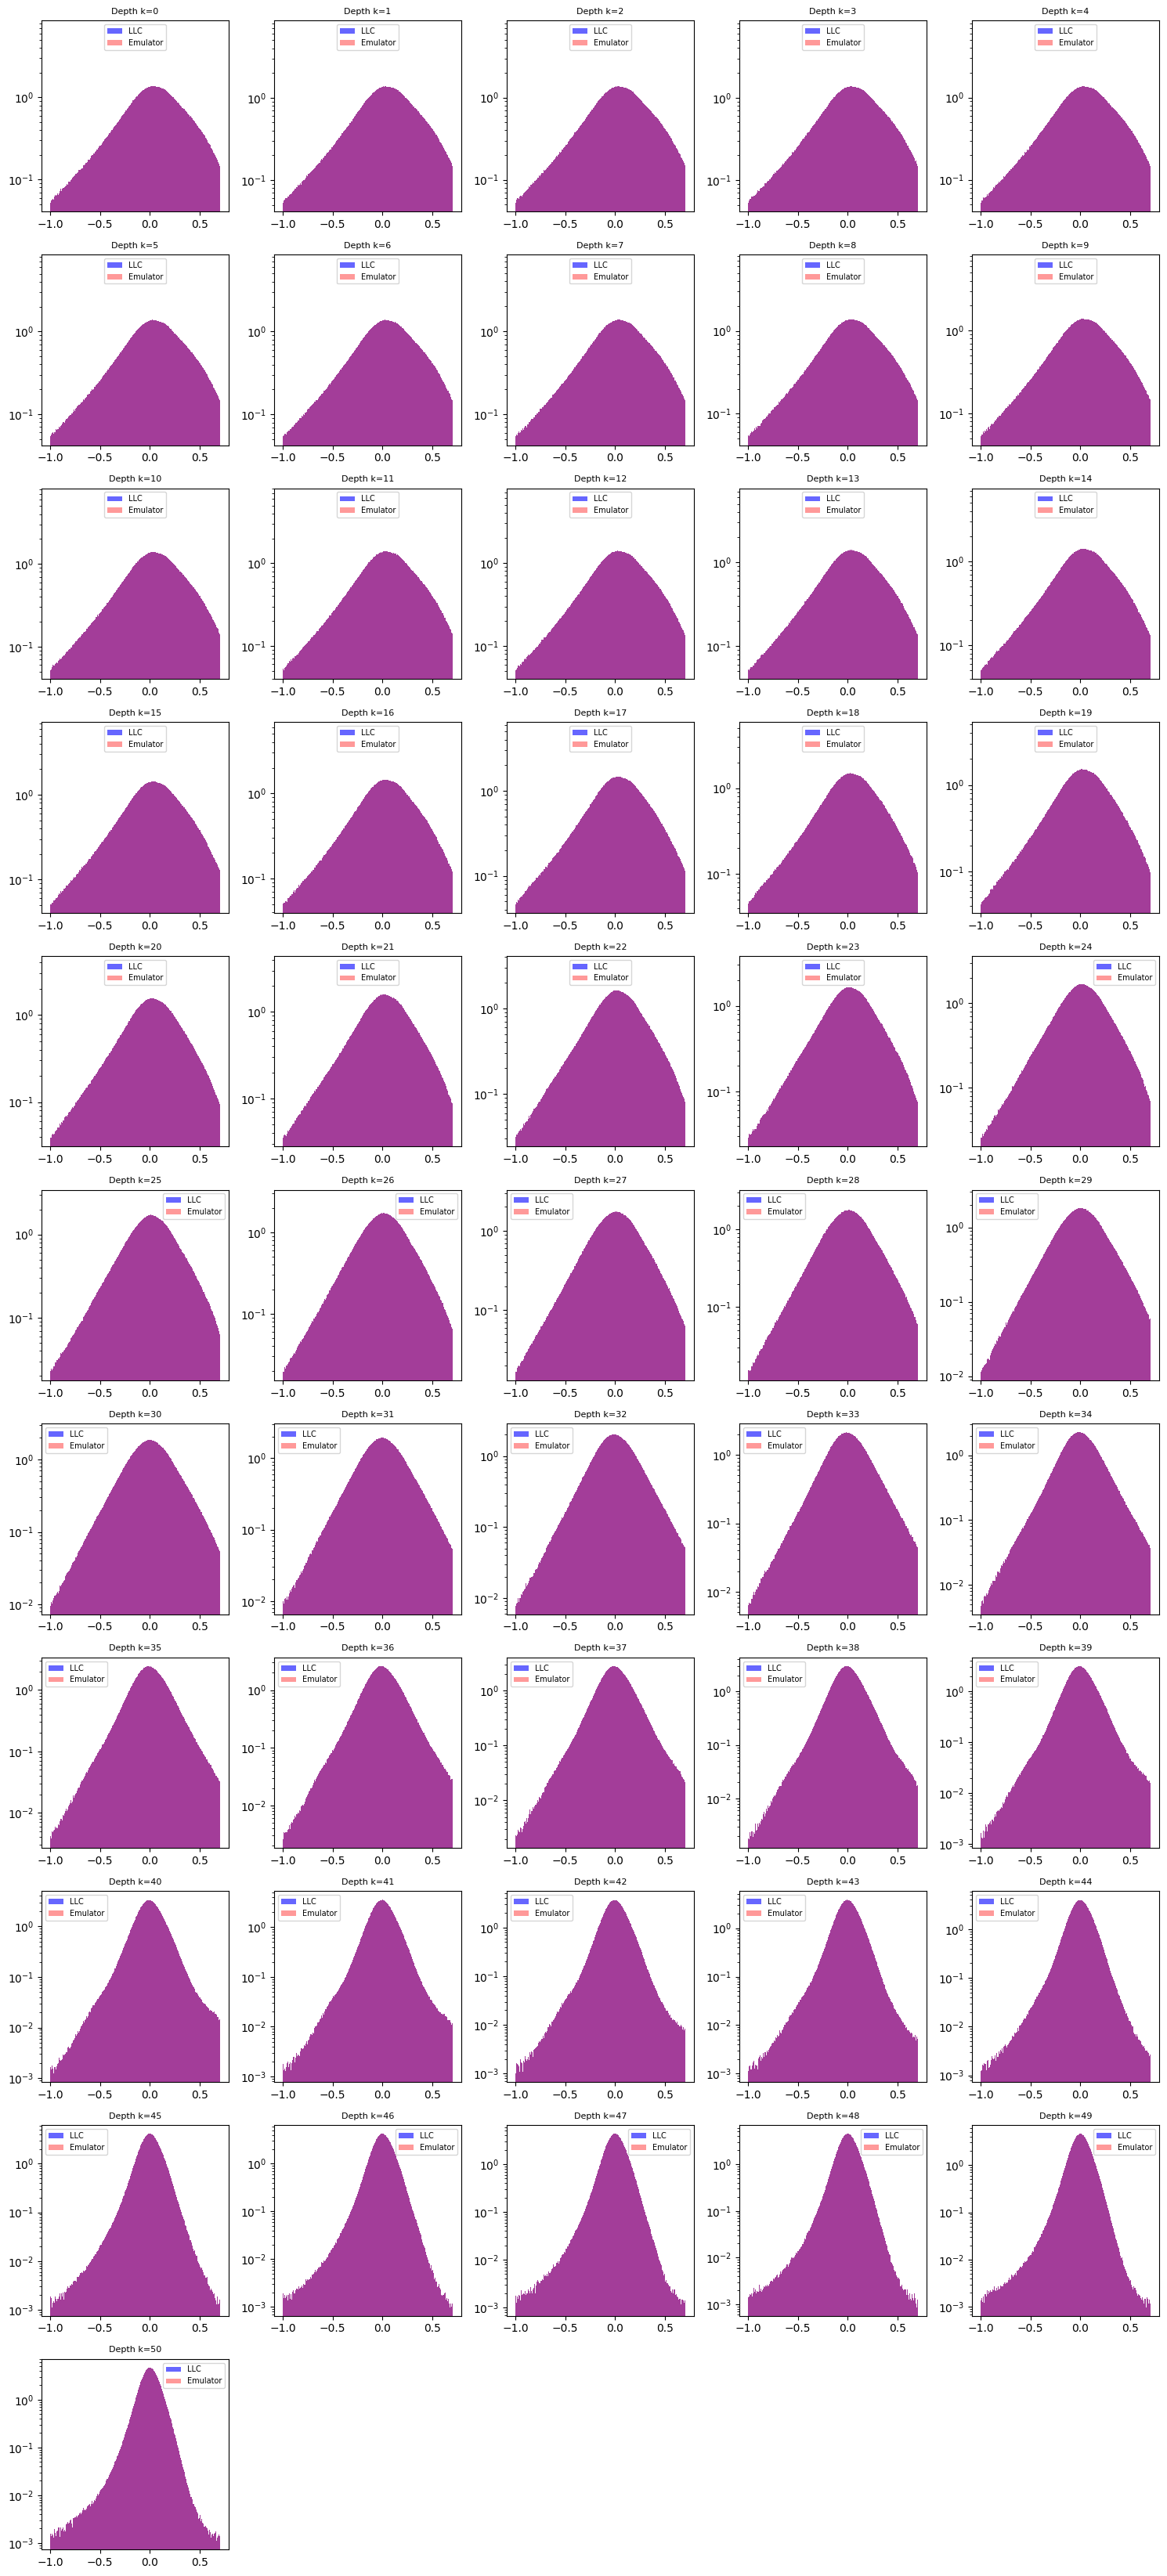

In [29]:
n_depths = len(vort_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(vort_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(vort_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.set_yscale('log')
    ax.legend(fontsize=7)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

## W

In [ ]:
# omega = 7.2921e-5
# f_0 = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

# Z = llc_patch['Z'].values
# DEPTH_THICKNESS = np.abs(np.diff(Z))

# u_x = (np.roll(llc_patch['U'].values, -1, axis=3) - np.roll(llc_patch['U'].values, 1, axis=3)) / 2
# v_y = (np.roll(llc_patch['V'].values, -1, axis=2) - np.roll(llc_patch['V'].values, 1, axis=2)) / 2
# divergence = u_x + v_y

# W_div = np.zeros_like(divergence)
# for k in range(divergence.shape[1] - 1, 0, -1):
#     W_div[:, k-1, :, :] = W_div[:, k, :, :] - divergence[:, k, :, :] * DEPTH_THICKNESS[k-1]

# W_div_normalized = W_div / f_0[np.newaxis, np.newaxis, :, :]
# W_div_normalized = np.clip(W_div_normalized, 
#                             np.nanpercentile(W_div_normalized, 1), 
#                             np.nanpercentile(W_div_normalized, 99))
# W_div_normalized = W_div_normalized / np.nanmax(np.abs(W_div_normalized))

# llc_patch['W_div'] = (('time', 'k', 'j', 'i'), W_div_normalized)

## Strain

In [6]:
omega = 7.2921e-5

# LLC Patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

u_x_llc = (np.roll(llc_patch['U'].values, -1, axis=3) - np.roll(llc_patch['U'].values, 1, axis=3)) / 2
u_y_llc = (np.roll(llc_patch['U'].values, -1, axis=2) - np.roll(llc_patch['U'].values, 1, axis=2)) / 2
v_x_llc = (np.roll(llc_patch['V'].values, -1, axis=3) - np.roll(llc_patch['V'].values, 1, axis=3)) / 2
v_y_llc = (np.roll(llc_patch['V'].values, -1, axis=2) - np.roll(llc_patch['V'].values, 1, axis=2)) / 2

sigma_n_llc = u_x_llc - v_y_llc
sigma_s_llc = v_x_llc + u_y_llc
sigma_llc = np.sqrt(sigma_n_llc**2 + sigma_s_llc**2)

sigma_llc_normalized = sigma_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
sigma_llc_normalized = np.clip(sigma_llc_normalized, 0, np.nanpercentile(sigma_llc_normalized, 99))
sigma_llc_normalized = sigma_llc_normalized / np.nanmax(sigma_llc_normalized)

llc_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_llc_normalized)



In [ ]:
# Emulator Patch
f_0_emulator = np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

u_x_emulator = (np.roll(emulator_patch['U'].values, -1, axis=3) - np.roll(emulator_patch['U'].values, 1, axis=3)) / 2
u_y_emulator = (np.roll(emulator_patch['U'].values, -1, axis=2) - np.roll(emulator_patch['U'].values, 1, axis=2)) / 2
v_x_emulator = (np.roll(emulator_patch['V'].values, -1, axis=3) - np.roll(emulator_patch['V'].values, 1, axis=3)) / 2
v_y_emulator = (np.roll(emulator_patch['V'].values, -1, axis=2) - np.roll(emulator_patch['V'].values, 1, axis=2)) / 2

sigma_n_emulator = u_x_emulator - v_y_emulator
sigma_s_emulator = v_x_emulator + u_y_emulator
sigma_emulator = np.sqrt(sigma_n_emulator**2 + sigma_s_emulator**2)

sigma_emulator_normalized = sigma_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]
sigma_emulator_normalized = np.clip(sigma_emulator_normalized, 0, np.nanpercentile(sigma_emulator_normalized, 99))
sigma_emulator_normalized = sigma_emulator_normalized / np.nanmax(sigma_emulator_normalized)

emulator_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_emulator_normalized)

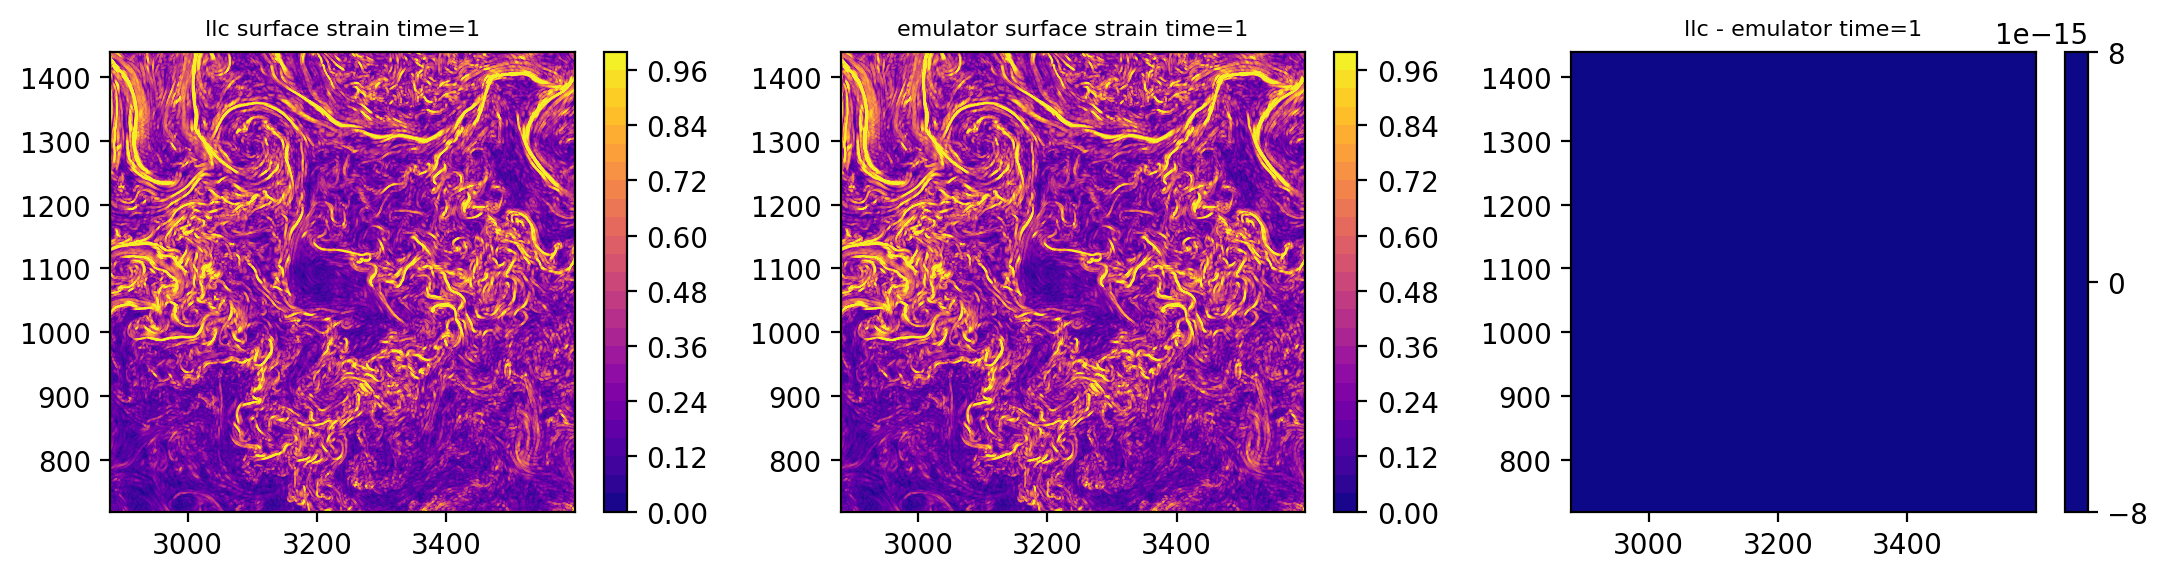

In [7]:
llc_vis = llc_patch.isel(time=1,k=0).strain
emulator_vis = emulator_patch.isel(time=1,k=0).strain

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="plasma",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface strain time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="plasma",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface strain time=1', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="plasma",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
strain_hist_llc = llc_patch.strain.stack(vals=['time','i','j']).values
strain_hist_emulator = emulator_patch.strain.stack(vals=['time','i','j']).values

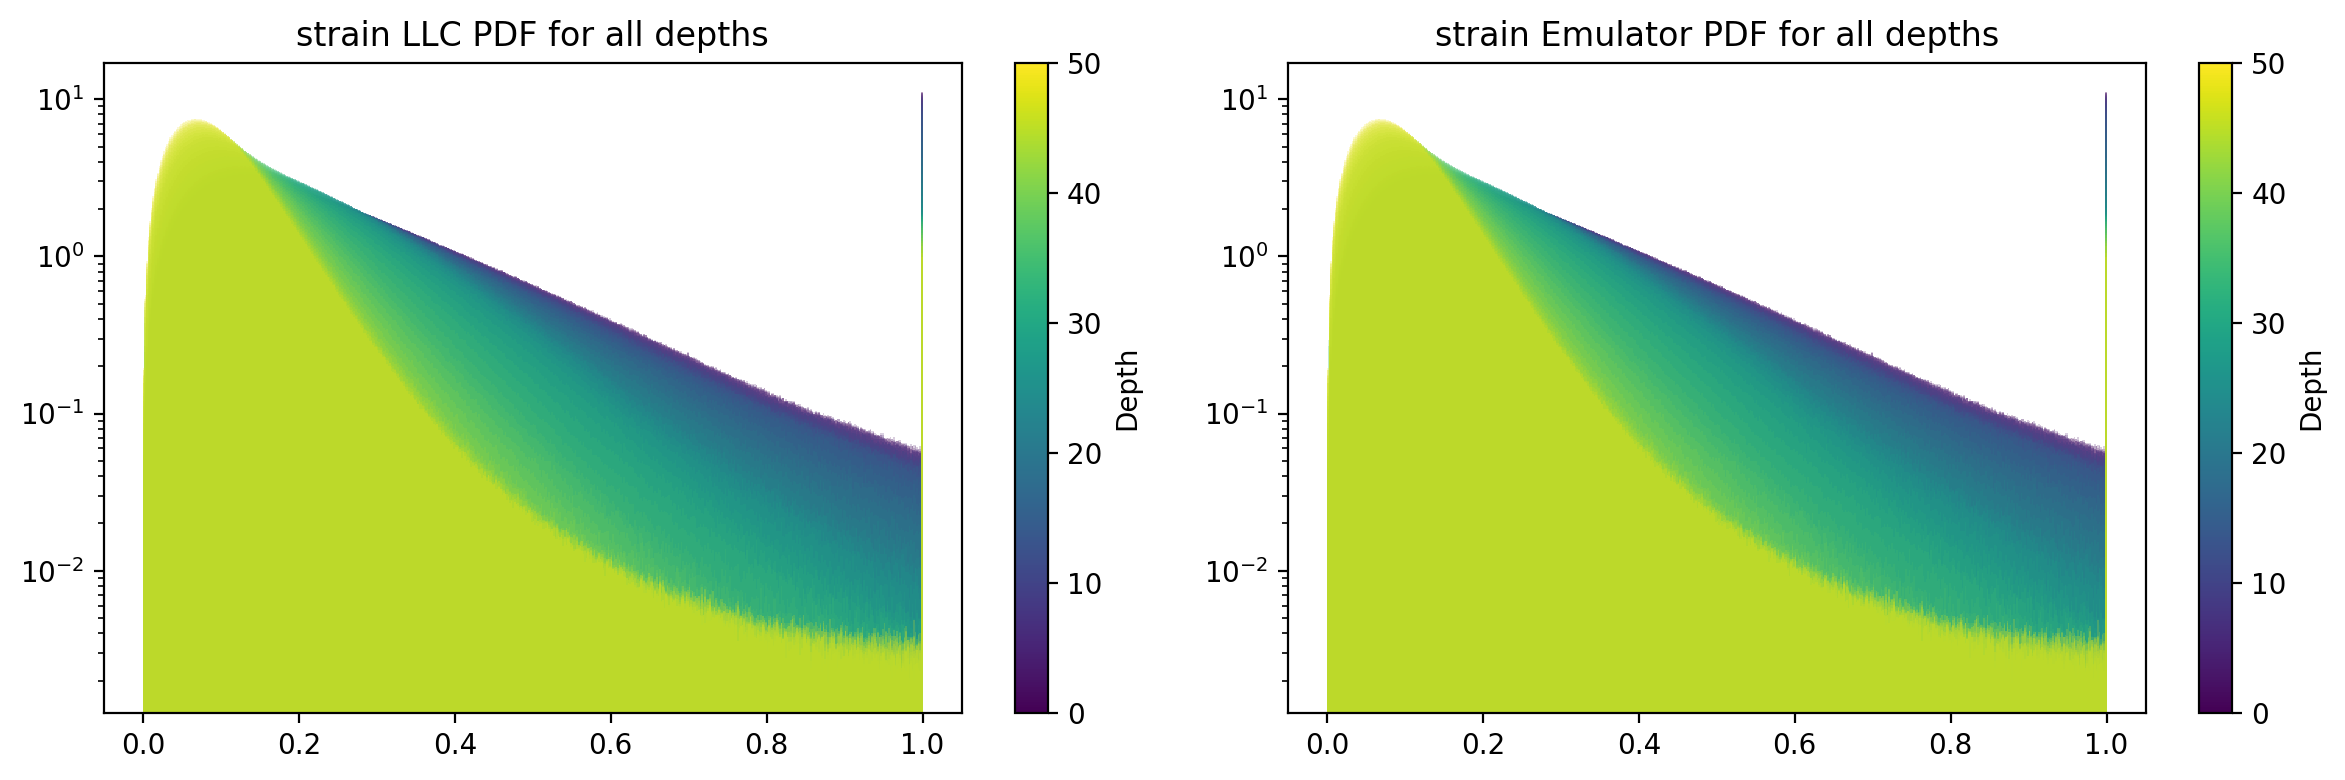

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

cm = [plt.cm.viridis(i/len(strain_hist_llc)) for i in range(len(strain_hist_llc))]
for k in range(0,len(strain_hist_llc)):
    ax1.hist(strain_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(strain_hist_llc)-1))
sm.set_array([])
ax1.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('strain LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(strain_hist_emulator)) for i in range(len(strain_hist_emulator))]
for k in range(0,len(strain_hist_emulator)):
    ax2.hist(strain_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(strain_hist_emulator)-1))
sm.set_array([])
ax2.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('strain Emulator PDF for all depths')
plt.tight_layout()
plt.show()

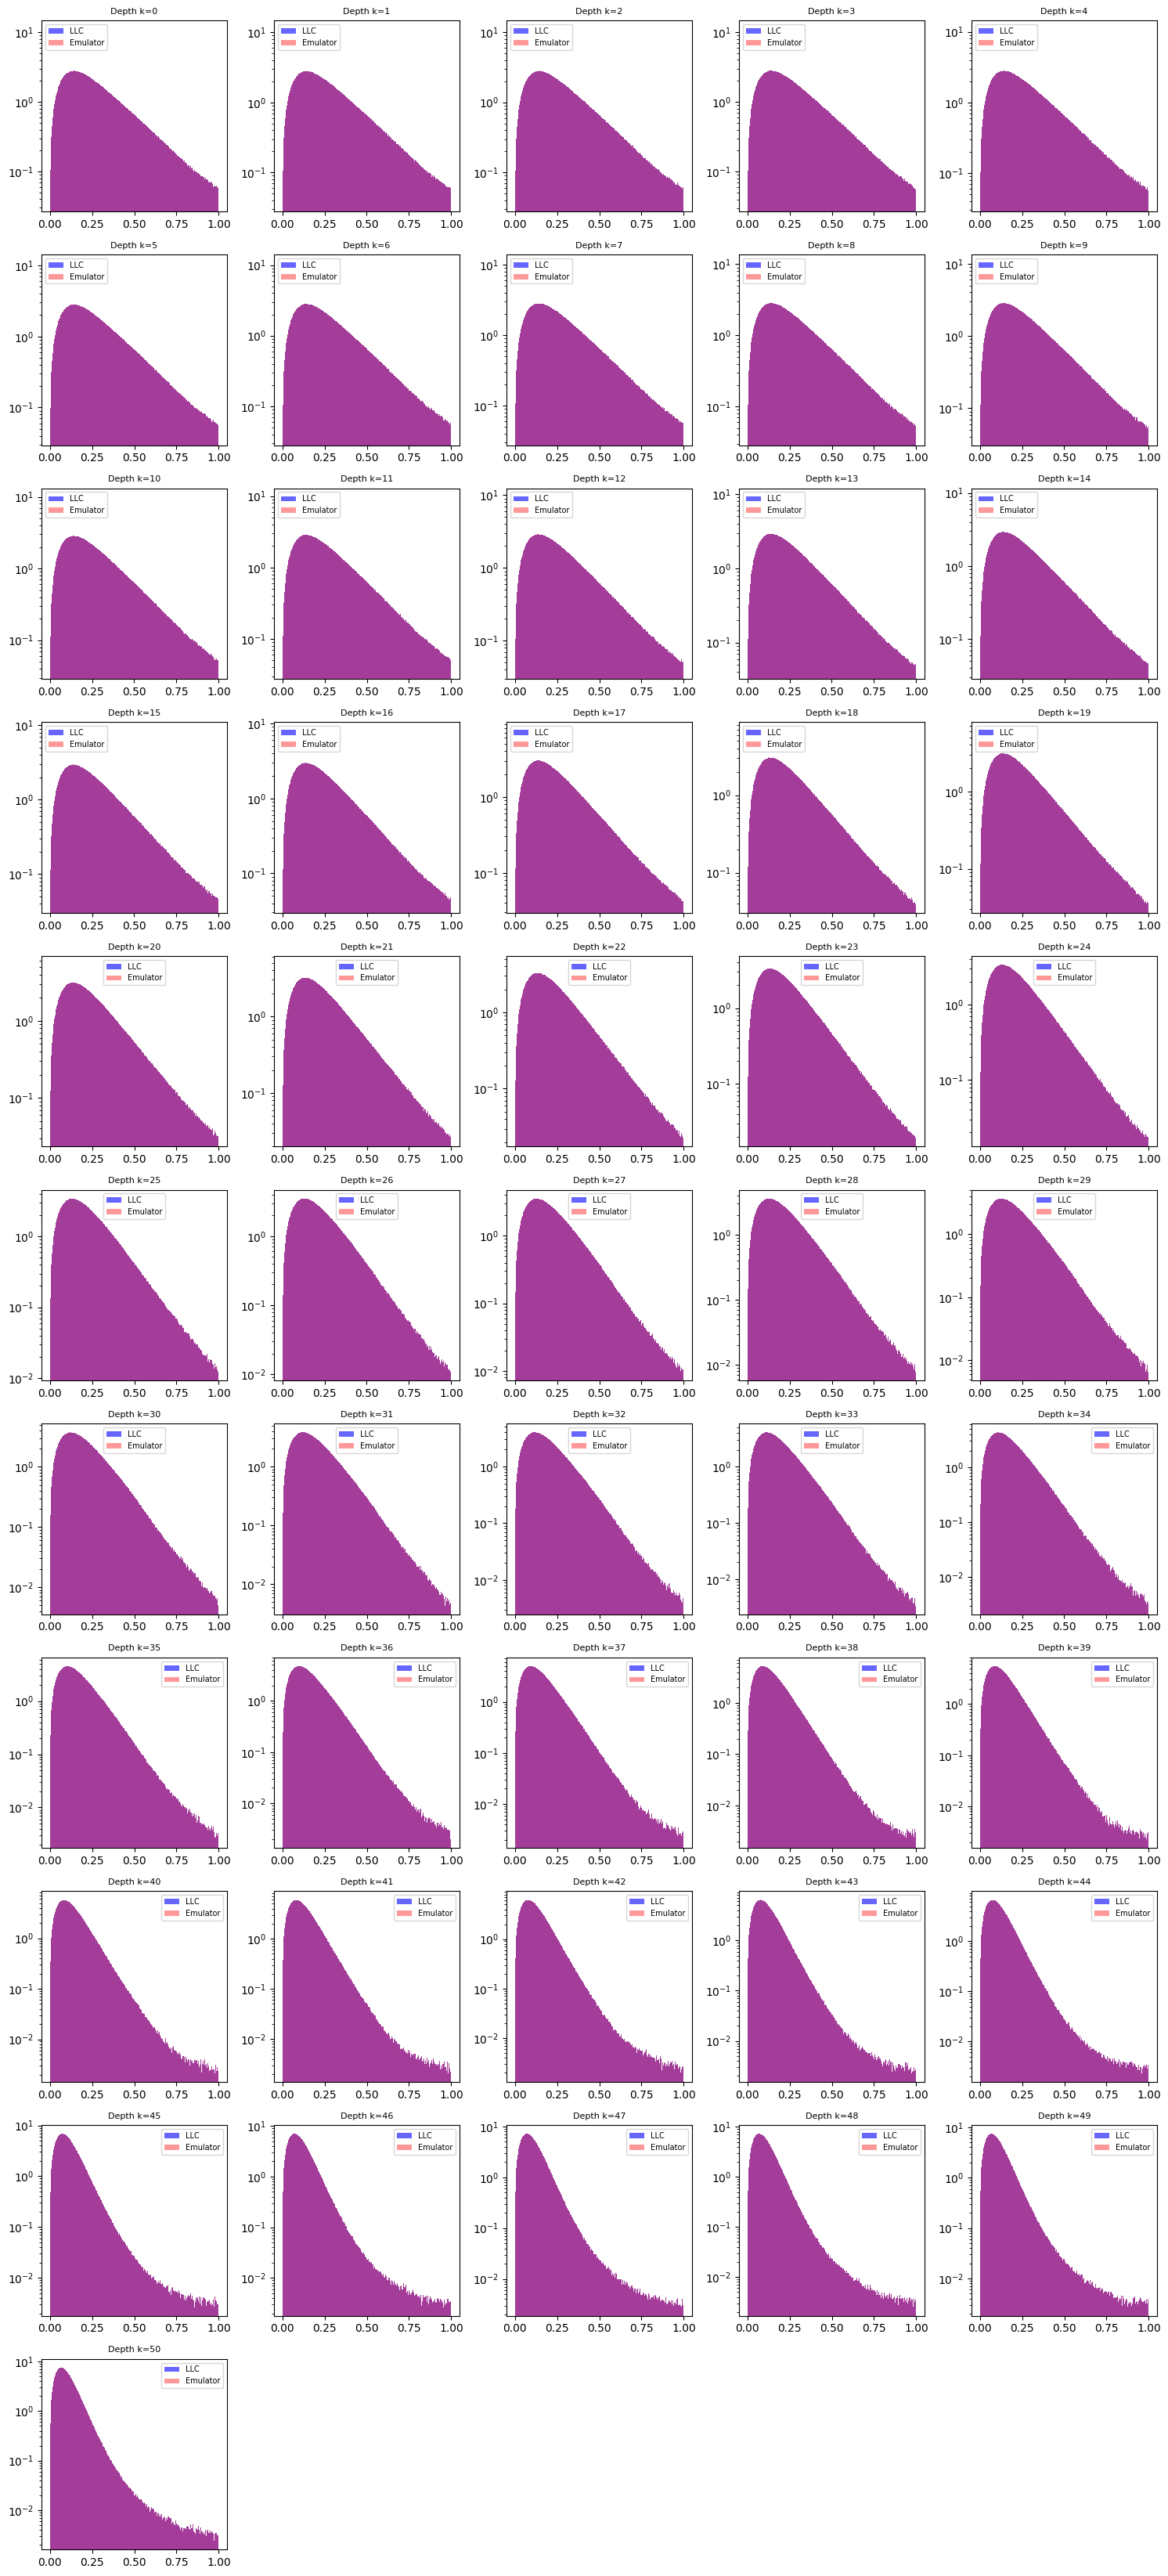

In [10]:
n_depths = len(strain_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(strain_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(strain_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.set_yscale('log')
    ax.legend(fontsize=7)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

## N2

In [9]:
g = 9.81
rho0 = 1025.0
alpha = 2e-4
beta = 7.4e-4

# LLC Patch
SA_llc = llc_patch['Salt'].values * (35.16504 / 35)
CT_llc = llc_patch['Theta'].values

dT_llc = np.diff(CT_llc, axis=1)
dS_llc = np.diff(SA_llc, axis=1)
dz_llc = np.diff(llc_patch.Z.values)
dz_llc = dz_llc[np.newaxis, :, np.newaxis, np.newaxis]

N2_llc = -(g / rho0) * (-alpha * rho0 * dT_llc / dz_llc + beta * rho0 * dS_llc / dz_llc)

llc_patch['N2'] = xr.DataArray(N2_llc, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': llc_patch['time'], 'k': llc_patch['k'][:-1],
                                        'j': llc_patch['j'], 'i': llc_patch['i']})

In [10]:
# Emulator Patch
SA_emulator = emulator_patch['Salt'].values * (35.16504 / 35)
CT_emulator = emulator_patch['Theta'].values

dT_emulator = np.diff(CT_emulator, axis=1)
dS_emulator = np.diff(SA_emulator, axis=1)
dz_emulator = np.diff(emulator_patch.Z.values)
dz_emulator = dz_emulator[np.newaxis, :, np.newaxis, np.newaxis]

N2_emulator = -(g / rho0) * (-alpha * rho0 * dT_emulator / dz_emulator + beta * rho0 * dS_emulator / dz_emulator)

emulator_patch['N2'] = xr.DataArray(N2_emulator, dims=['time', 'k', 'j', 'i'], 
                                    coords={'time': emulator_patch['time'], 'k': emulator_patch['k'][:-1],
                                            'j': emulator_patch['j'], 'i': emulator_patch['i']})

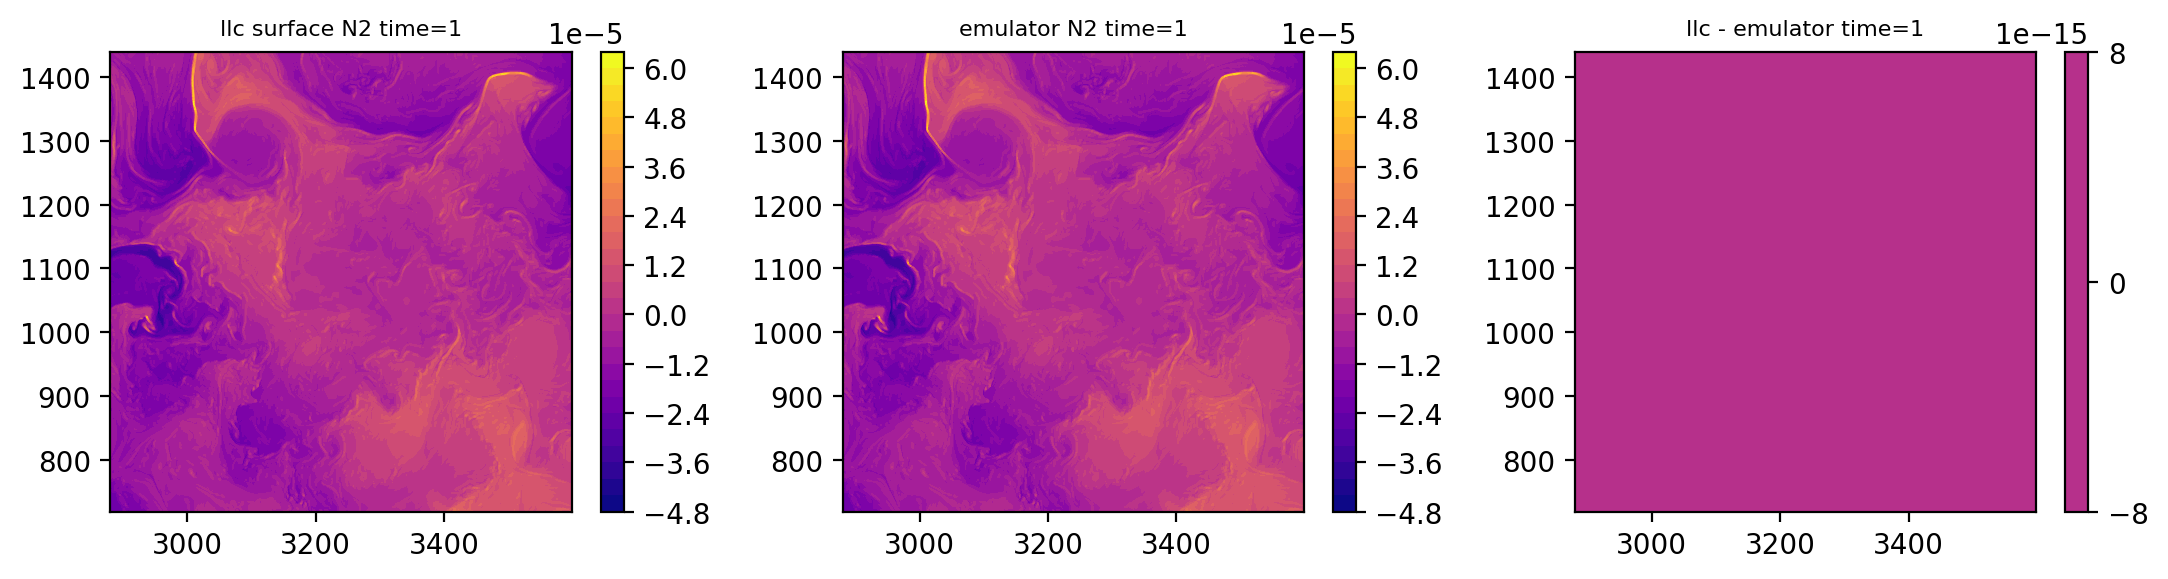

In [ ]:
llc_vis = llc_patch.isel(time=1,k=0).N2
emulator_vis = emulator_patch.isel(time=1,k=0).N2

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="plasma",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface N2 time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="cividis",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator N2 time=1', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="cividis",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
N2_hist_llc = llc_patch.N2.stack(vals=['time','i','j']).values[:-1]
N2_hist_emulator = emulator_patch.N2.stack(vals=['time','i','j']).values[:-1]

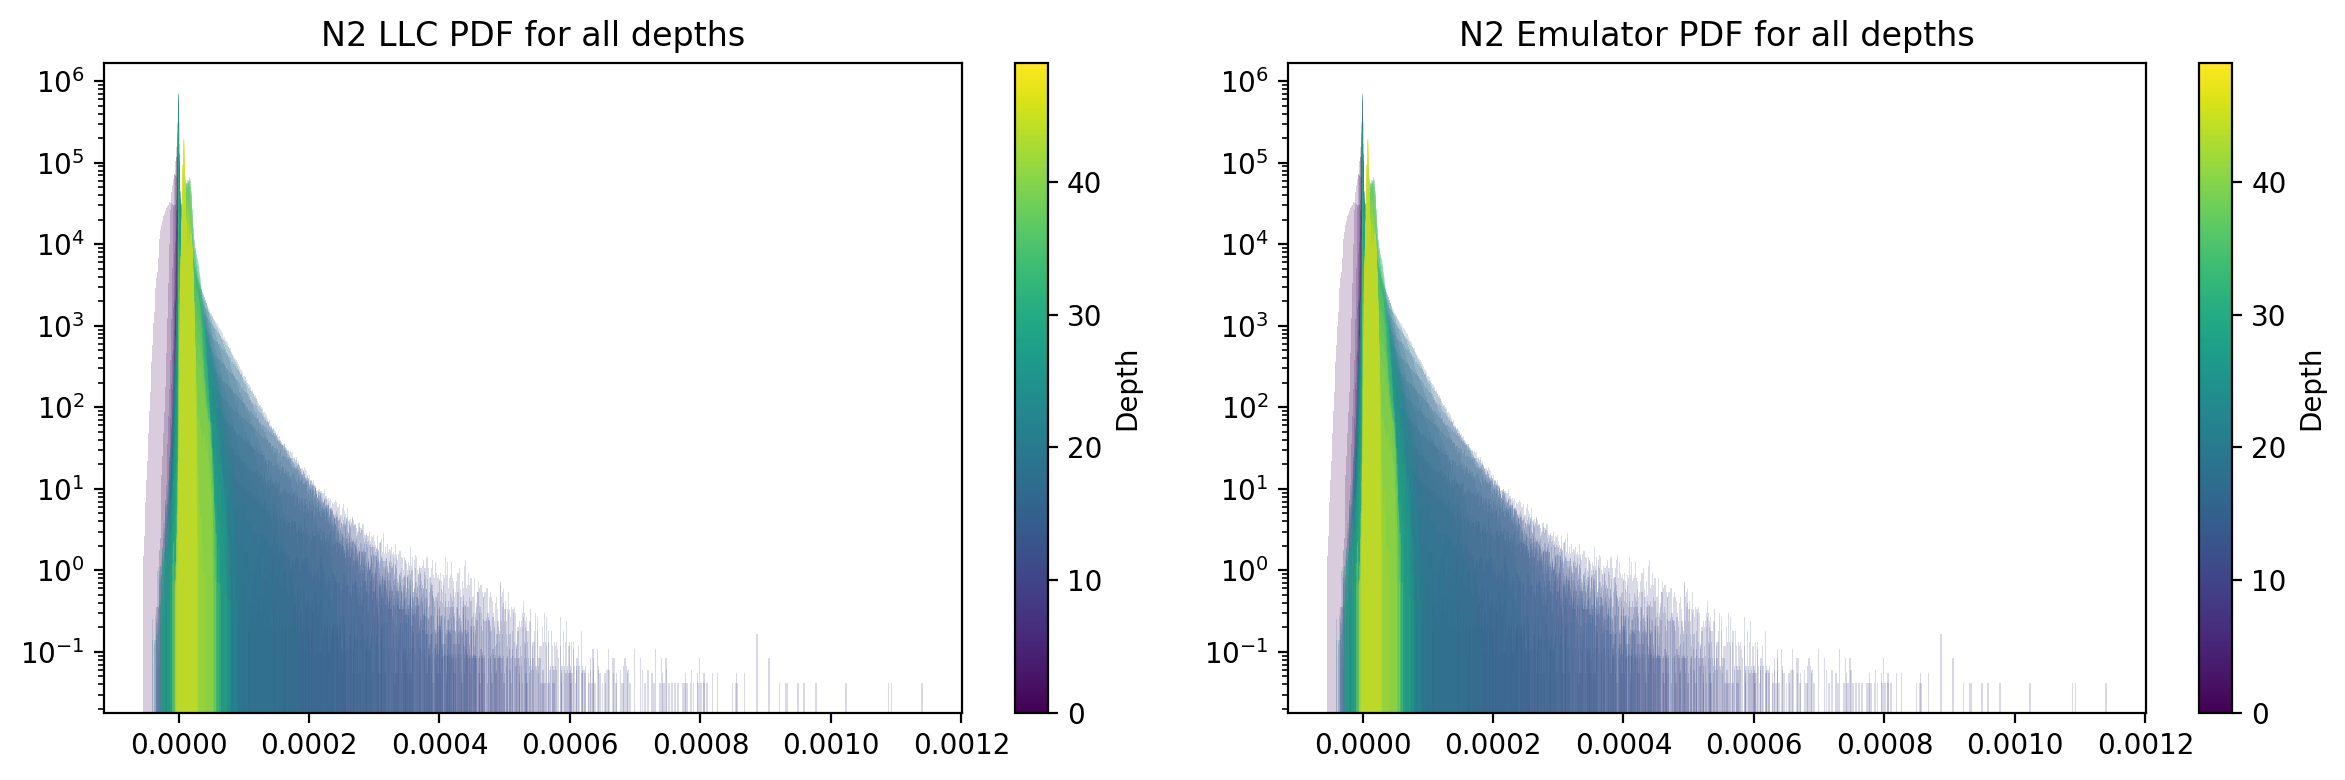

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

cm = [plt.cm.viridis(i/len(N2_hist_llc)) for i in range(len(N2_hist_llc))]
for k in range(0,len(N2_hist_llc)):
    ax1.hist(N2_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(N2_hist_llc)-1))
sm.set_array([])
ax1.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('N2 LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(N2_hist_emulator)) for i in range(len(N2_hist_emulator))]
for k in range(0,len(N2_hist_emulator)):
    ax2.hist(N2_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(N2_hist_emulator)-1))
sm.set_array([])
ax2.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('N2 Emulator PDF for all depths')
plt.tight_layout()
plt.show()

/orcd/home/002/codycruz/Ocean_Emulator/.venv/lib64/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


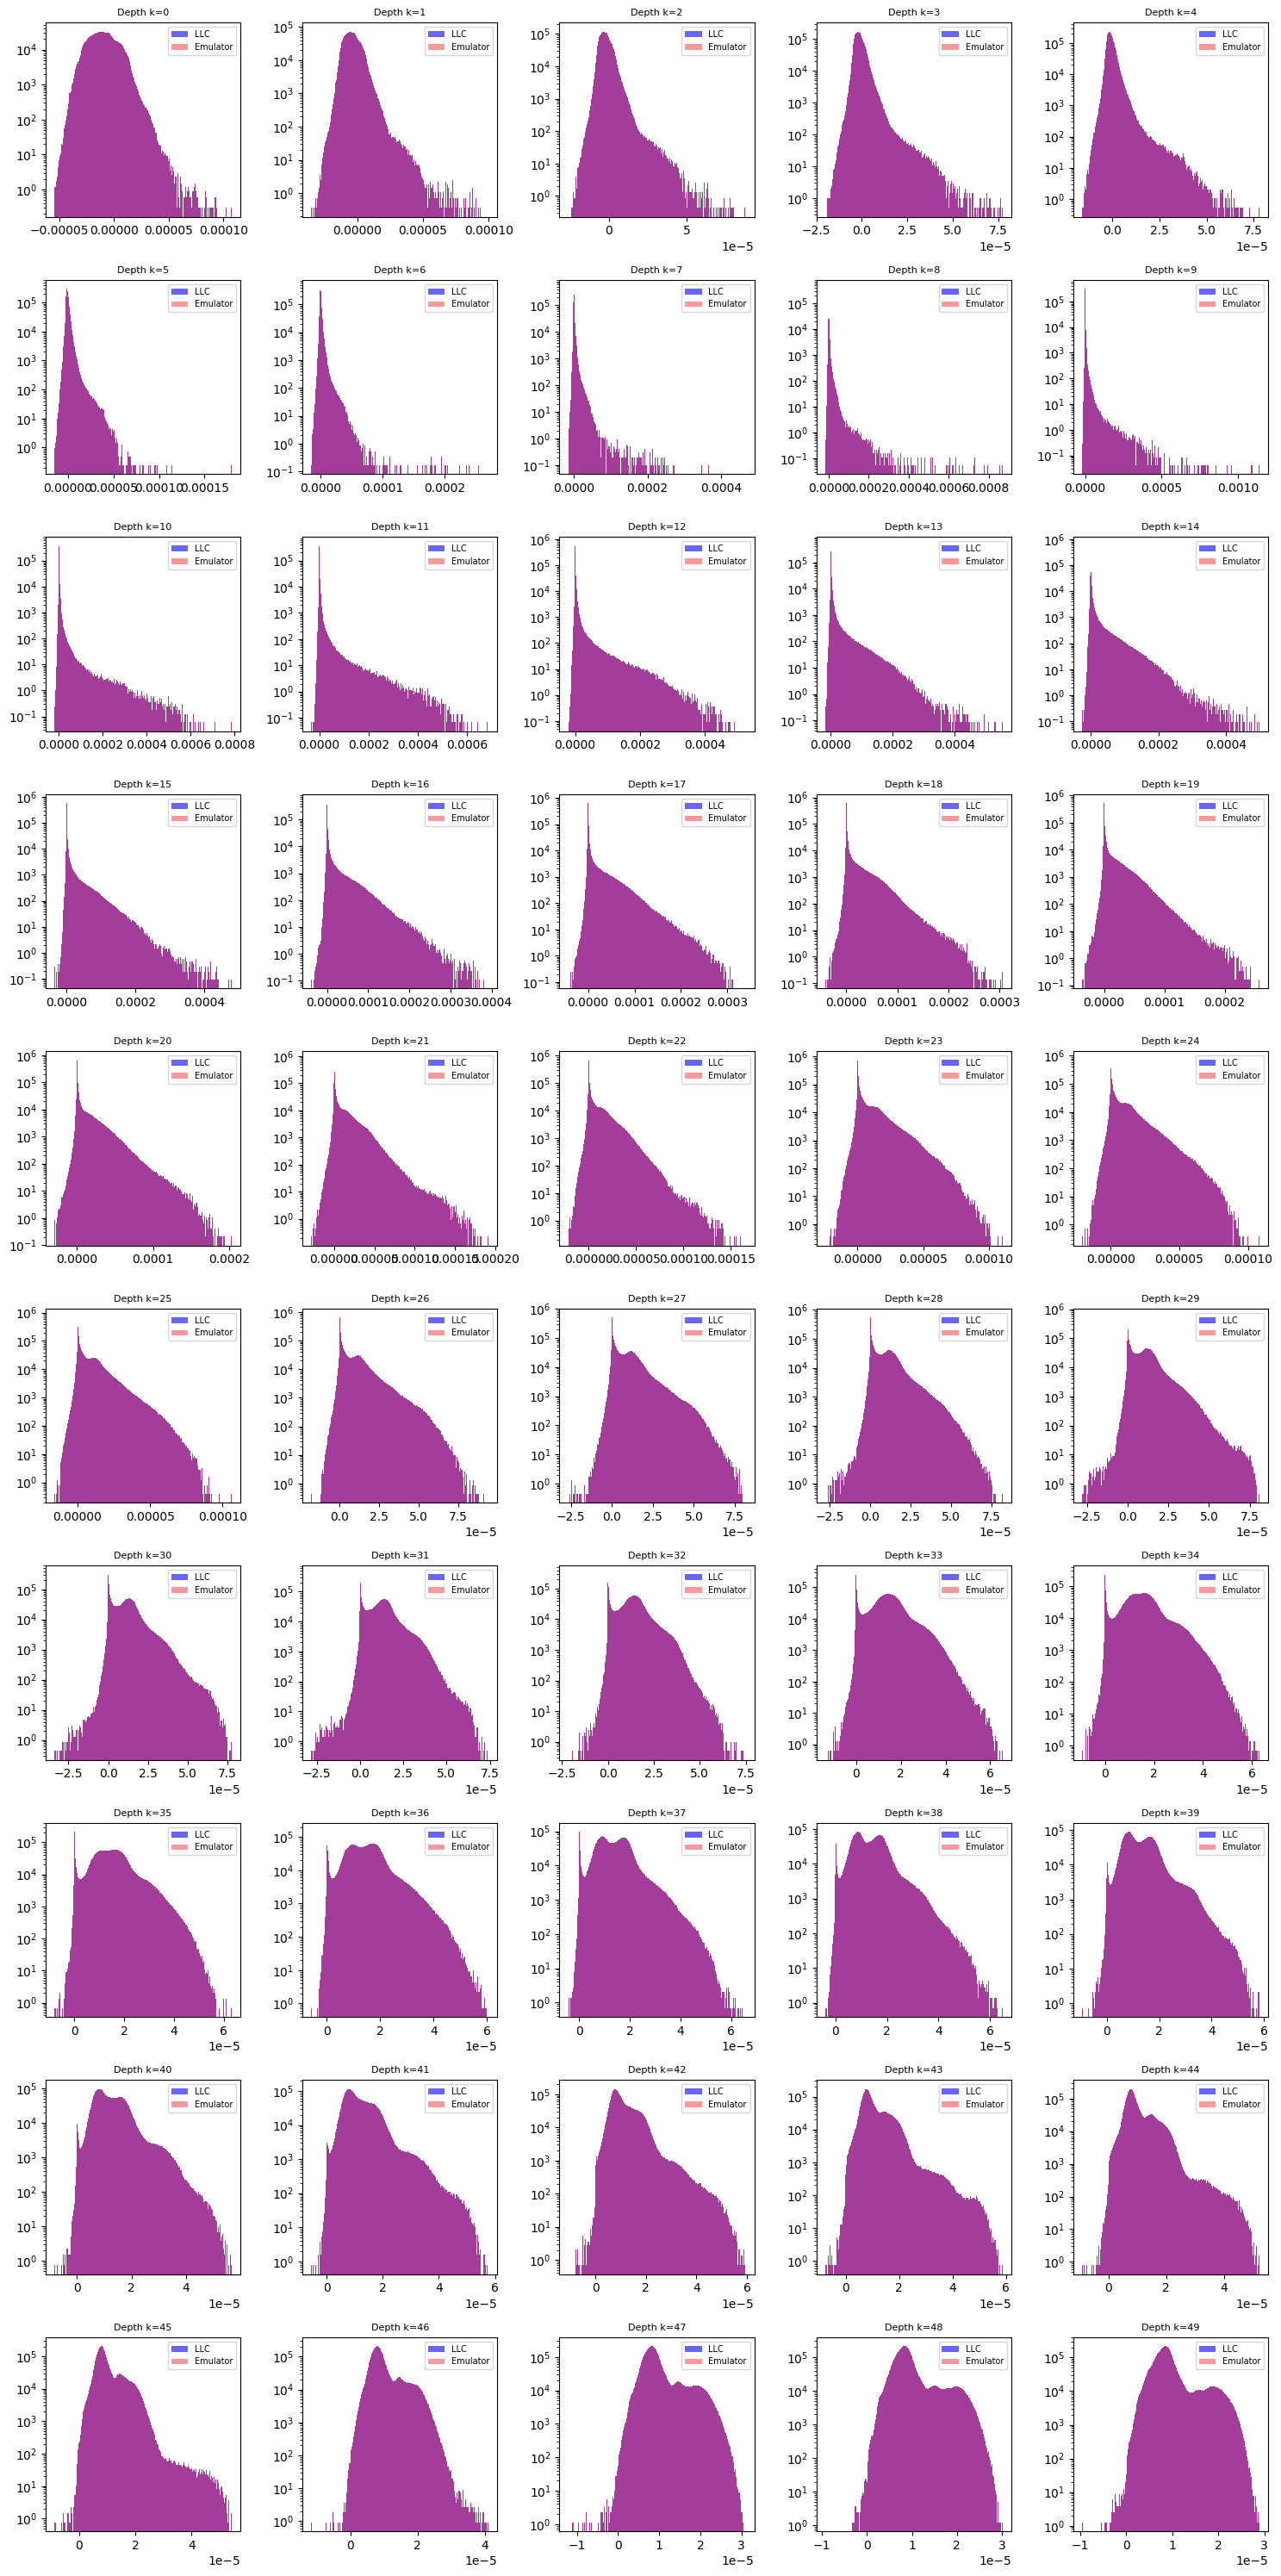

In [14]:
n_depths = len(N2_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(N2_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(N2_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.set_yscale('log')
    ax.legend(fontsize=7)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

## Ri

In [12]:
llc_Ri = llc_patch.N2 / (llc_patch.S2.isel(k=slice(0,-1)) + 1e-10)

llc_patch['Ri'] = xr.DataArray(llc_Ri, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': llc_patch['time'], 'k': llc_patch['k'][:-1],
                                        'j': llc_patch['j'], 'i': llc_patch['i']})

In [13]:
emulator_Ri = emulator_patch.N2 / (emulator_patch.S2.isel(k=slice(0,-1)) + 1e-10)

emulator_patch['Ri'] = xr.DataArray(emulator_Ri, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': emulator_patch['time'], 'k': emulator_patch['k'][:-1],
                                        'j': emulator_patch['j'], 'i': emulator_patch['i']})

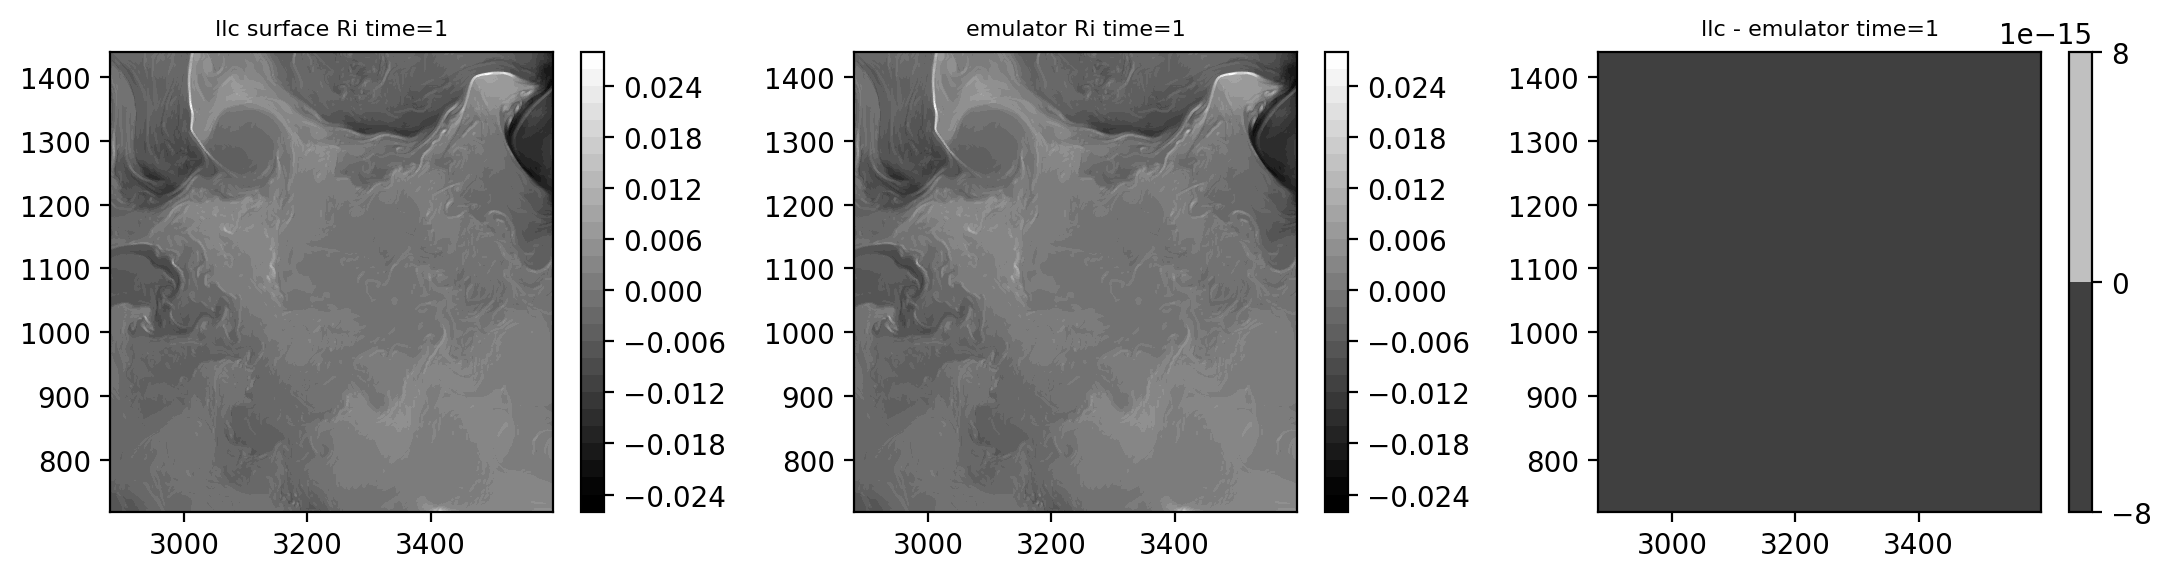

In [28]:
llc_vis = llc_patch.isel(time=1,k=0).Ri
emulator_vis = emulator_patch.isel(time=1,k=0).Ri

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="gray",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
ax1.contour(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis.values, \
        levels=[0.25], colors='yellow', linewidths=0.5)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface Ri time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="gray",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
ax2.contour(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis.values, \
        levels=[0.25], colors='yellow', linewidths=0.5)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator Ri time=1', fontsize=8)

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="gray", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

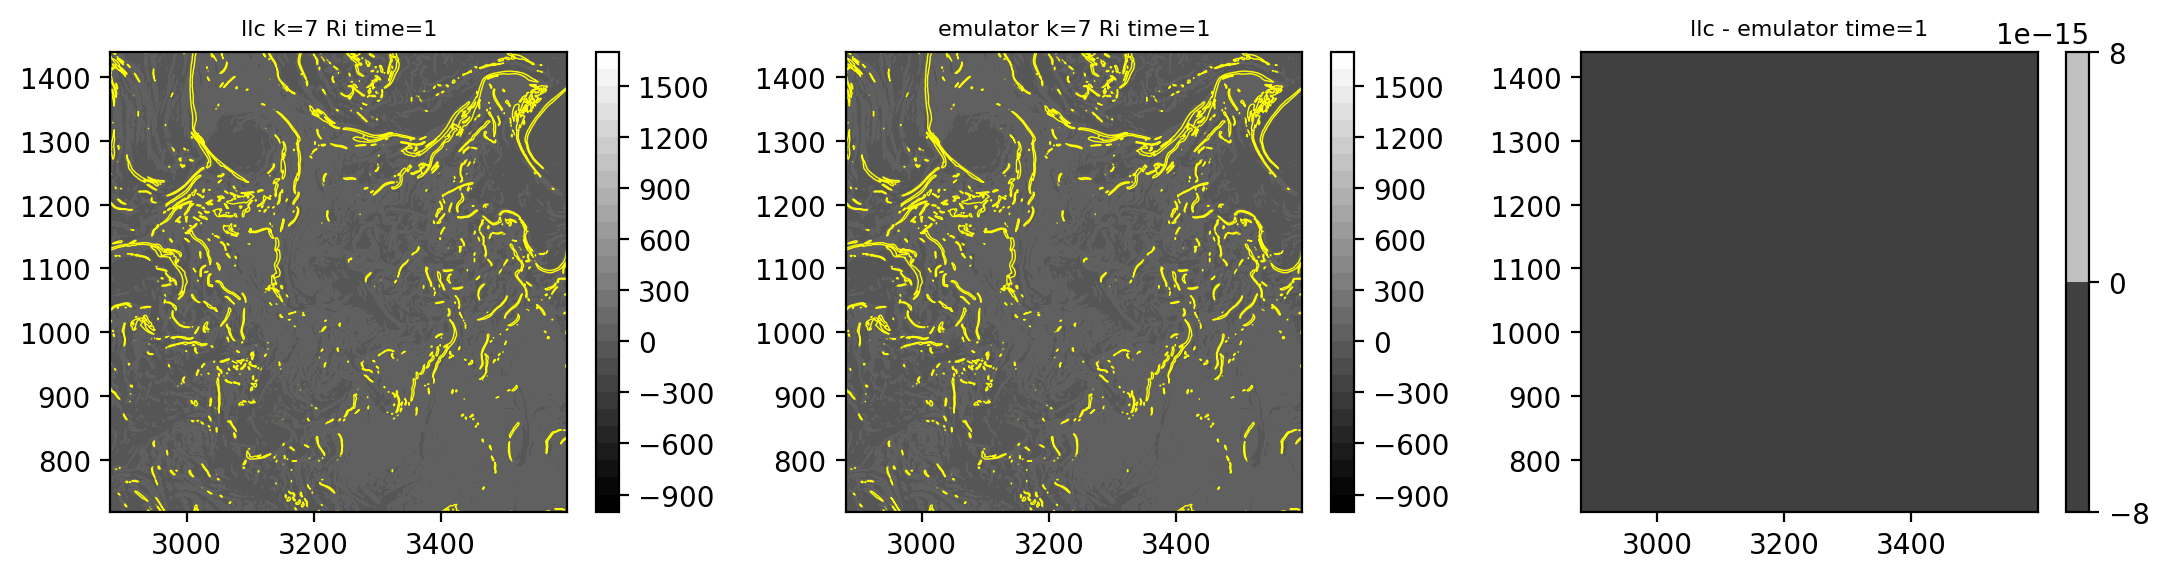

In [30]:
llc_vis = llc_patch.isel(time=1,k=9).Ri
emulator_vis = emulator_patch.isel(time=1,k=9).Ri

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="gray",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
ax1.contour(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis.values, \
        levels=[0.25], colors='yellow', linewidths=0.5)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc k=7 Ri time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="gray",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
ax2.contour(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis.values, \
        levels=[0.25], colors='yellow', linewidths=0.5)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator k=7 Ri time=1', fontsize=8)

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="gray", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
Ri_hist_llc = llc_patch.Ri.stack(vals=['time','i','j']).values[:-1]
Ri_hist_emulator = emulator_patch.Ri.stack(vals=['time','i','j']).values[:-1]

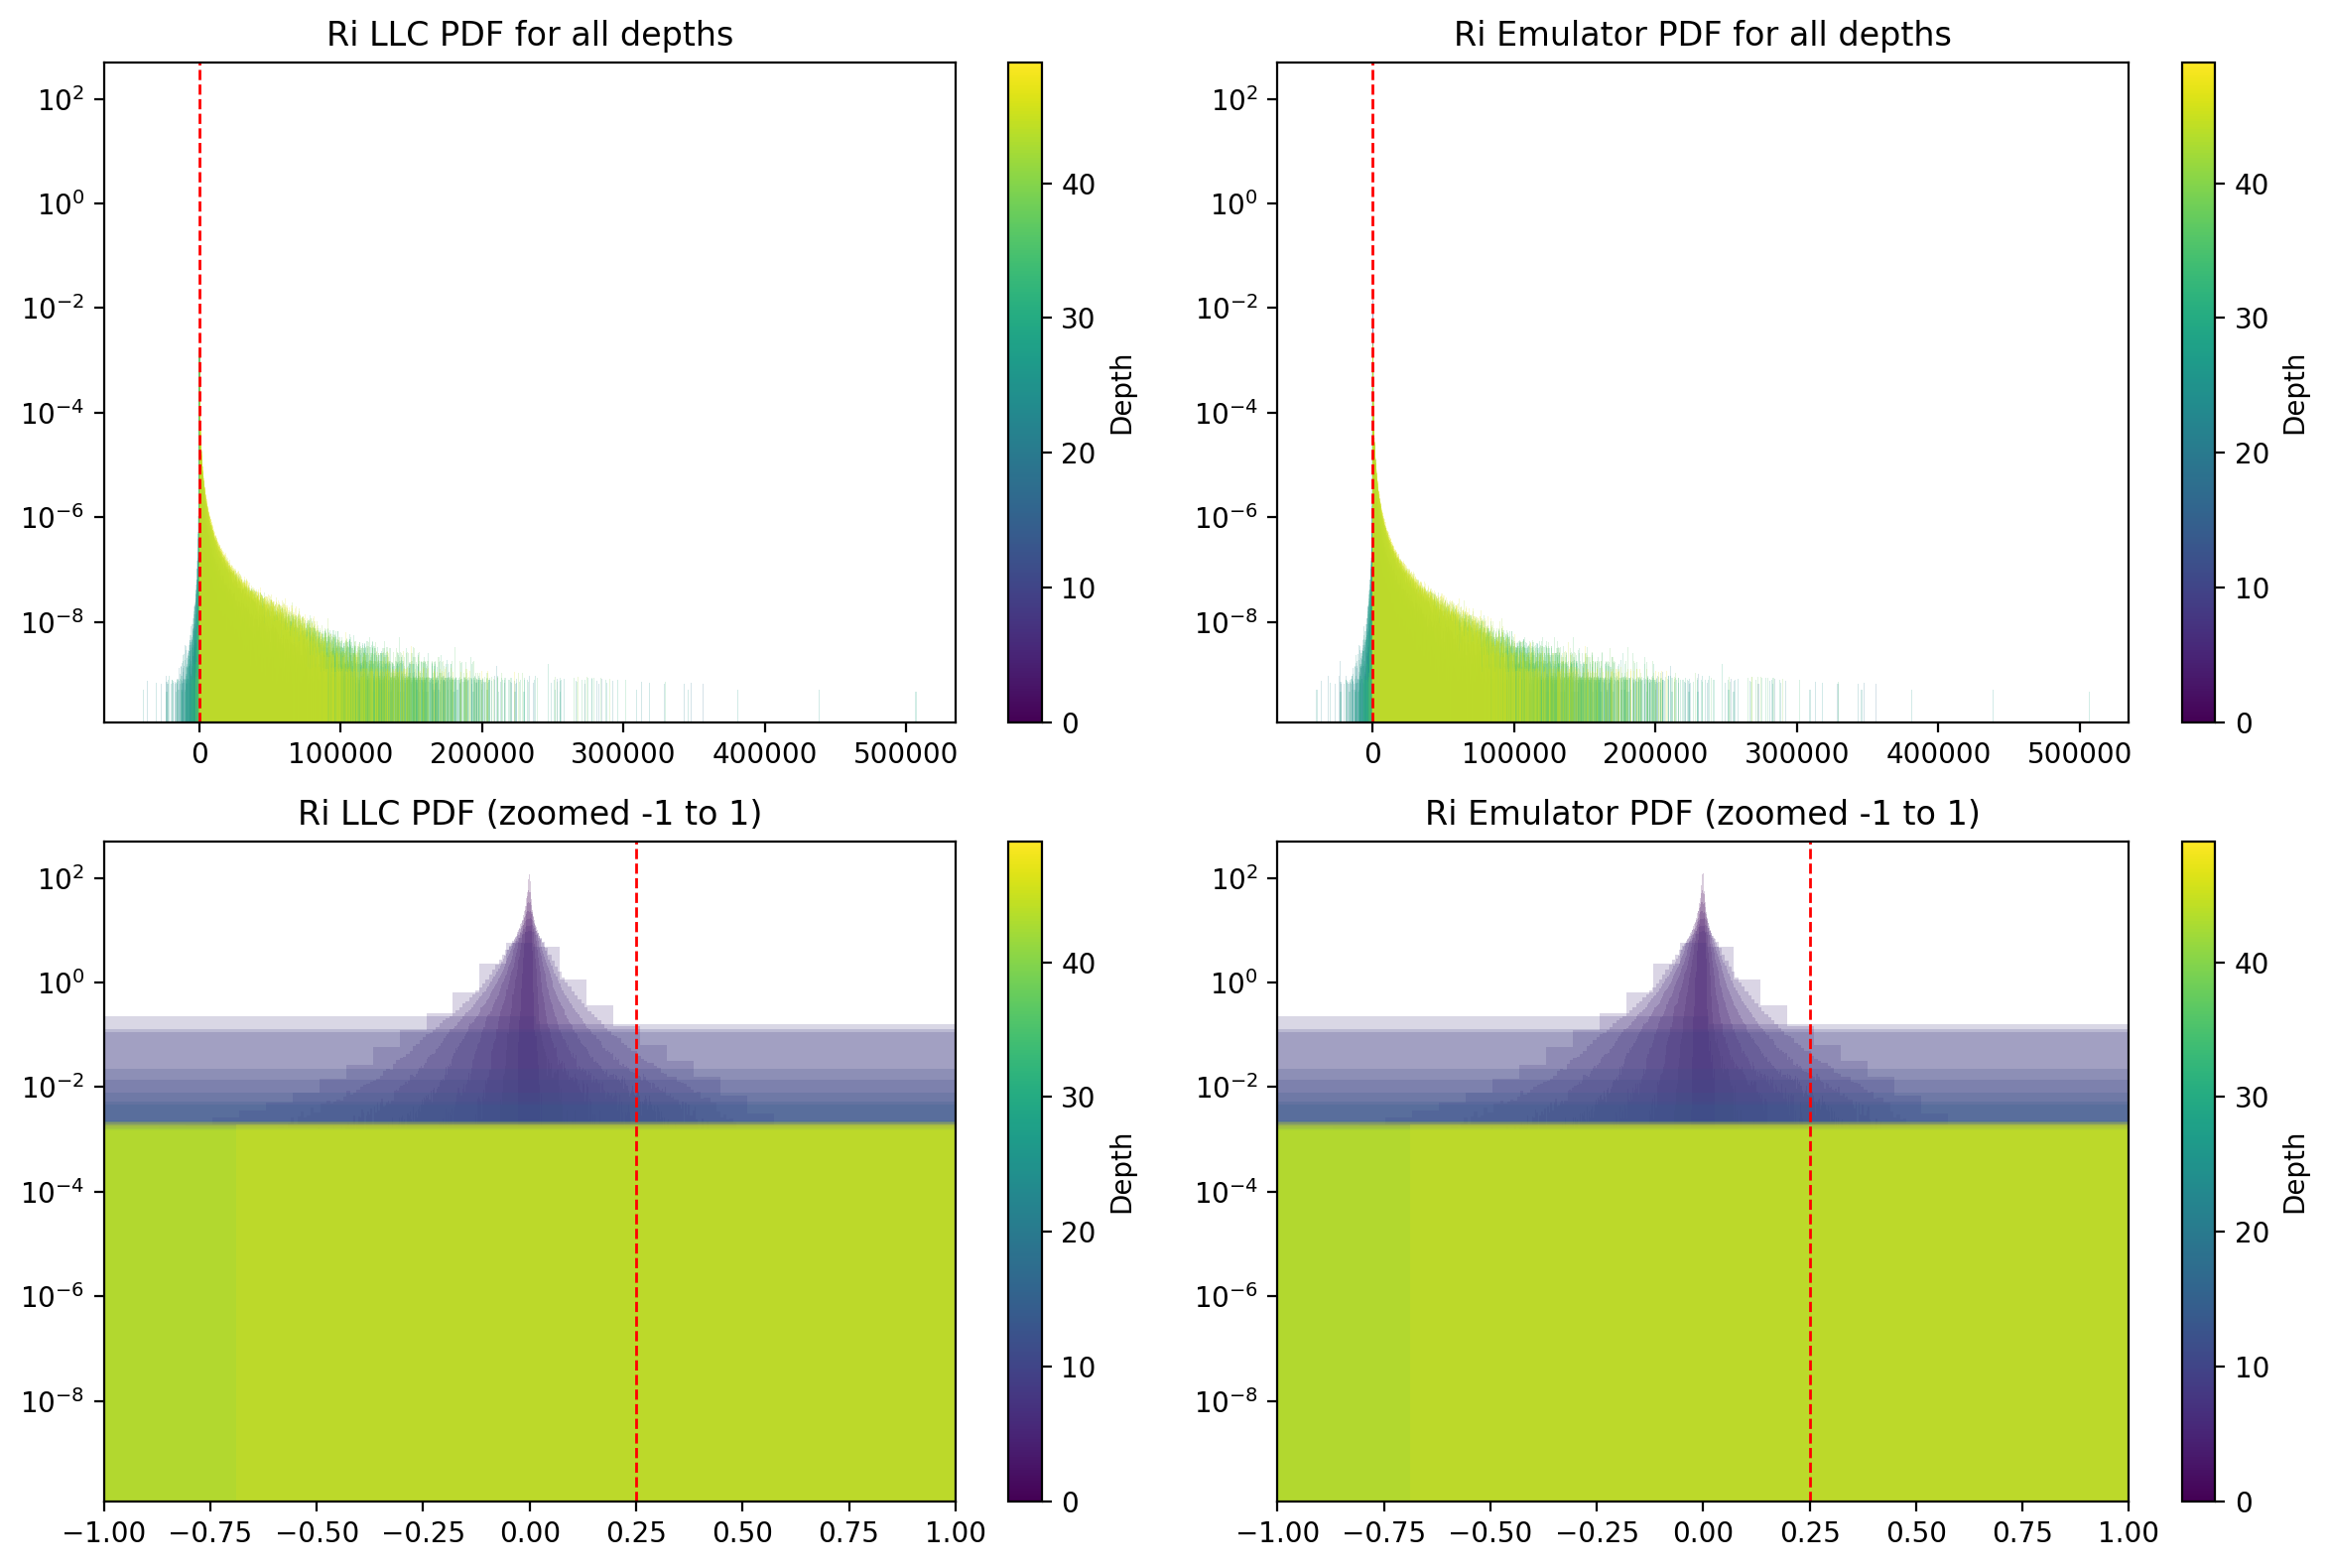

In [31]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8), dpi=200)

# Top row: full range
cm = [plt.cm.viridis(i/len(Ri_hist_llc)) for i in range(len(Ri_hist_llc))]
for k in range(0,len(Ri_hist_llc)):
    ax1.hist(Ri_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
ax1.axvline(x=0.25, color='red', linestyle='--', linewidth=1)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Ri_hist_llc)-1))
sm.set_array([])
ax1.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('Ri LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(Ri_hist_emulator)) for i in range(len(Ri_hist_emulator))]
for k in range(0,len(Ri_hist_emulator)):
    ax2.hist(Ri_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
ax2.axvline(x=0.25, color='red', linestyle='--', linewidth=1)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Ri_hist_emulator)-1))
sm.set_array([])
ax2.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('Ri Emulator PDF for all depths')

# Bottom row: zoomed to -1 to 1
cm = [plt.cm.viridis(i/len(Ri_hist_llc)) for i in range(len(Ri_hist_llc))]
for k in range(0,len(Ri_hist_llc)):
    ax3.hist(Ri_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
ax3.axvline(x=0.25, color='red', linestyle='--', linewidth=1)
ax3.set_xlim(-1, 1)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Ri_hist_llc)-1))
sm.set_array([])
ax3.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax3)
ax3.set_title('Ri LLC PDF (zoomed -1 to 1)')

cm = [plt.cm.viridis(i/len(Ri_hist_emulator)) for i in range(len(Ri_hist_emulator))]
for k in range(0,len(Ri_hist_emulator)):
    ax4.hist(Ri_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
ax4.axvline(x=0.25, color='red', linestyle='--', linewidth=1)
ax4.set_xlim(-1, 1)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Ri_hist_emulator)-1))
sm.set_array([])
ax4.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax4)
ax4.set_title('Ri Emulator PDF (zoomed -1 to 1)')

plt.tight_layout()
plt.show()

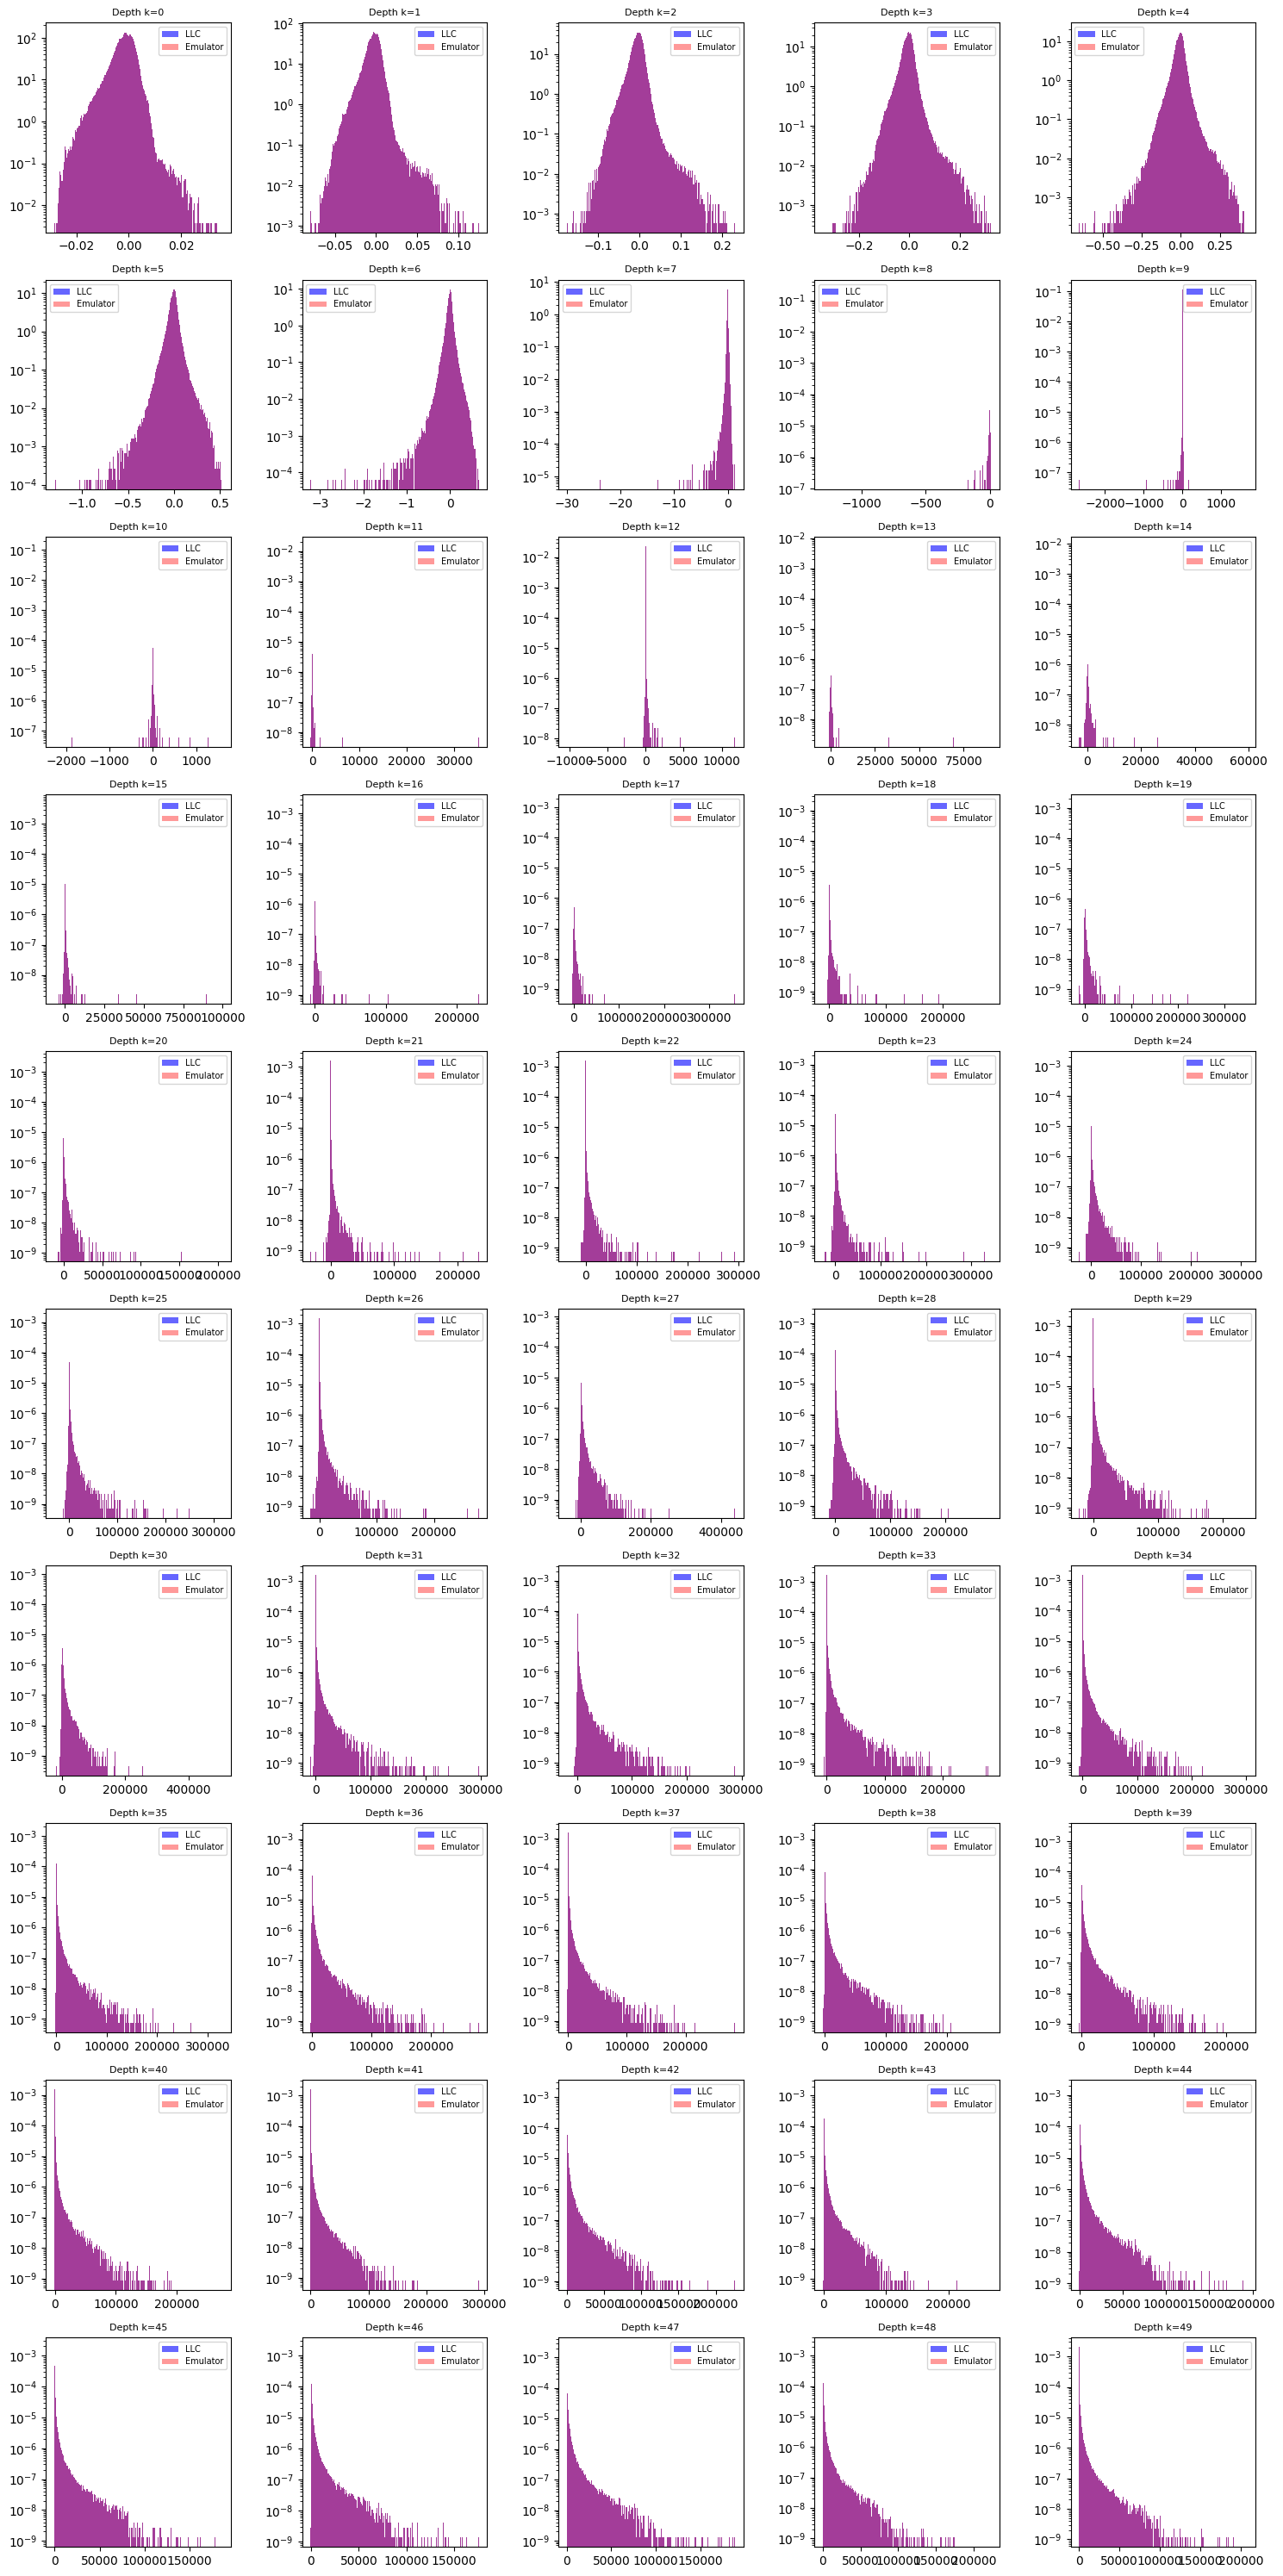

In [ ]:
n_depths = len(Ri_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(Ri_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(Ri_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.set_yscale('log')
    ax.legend(fontsize=7)
    ax.axvline(x=0.25, color='red', linestyle='--', linewidth=1)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

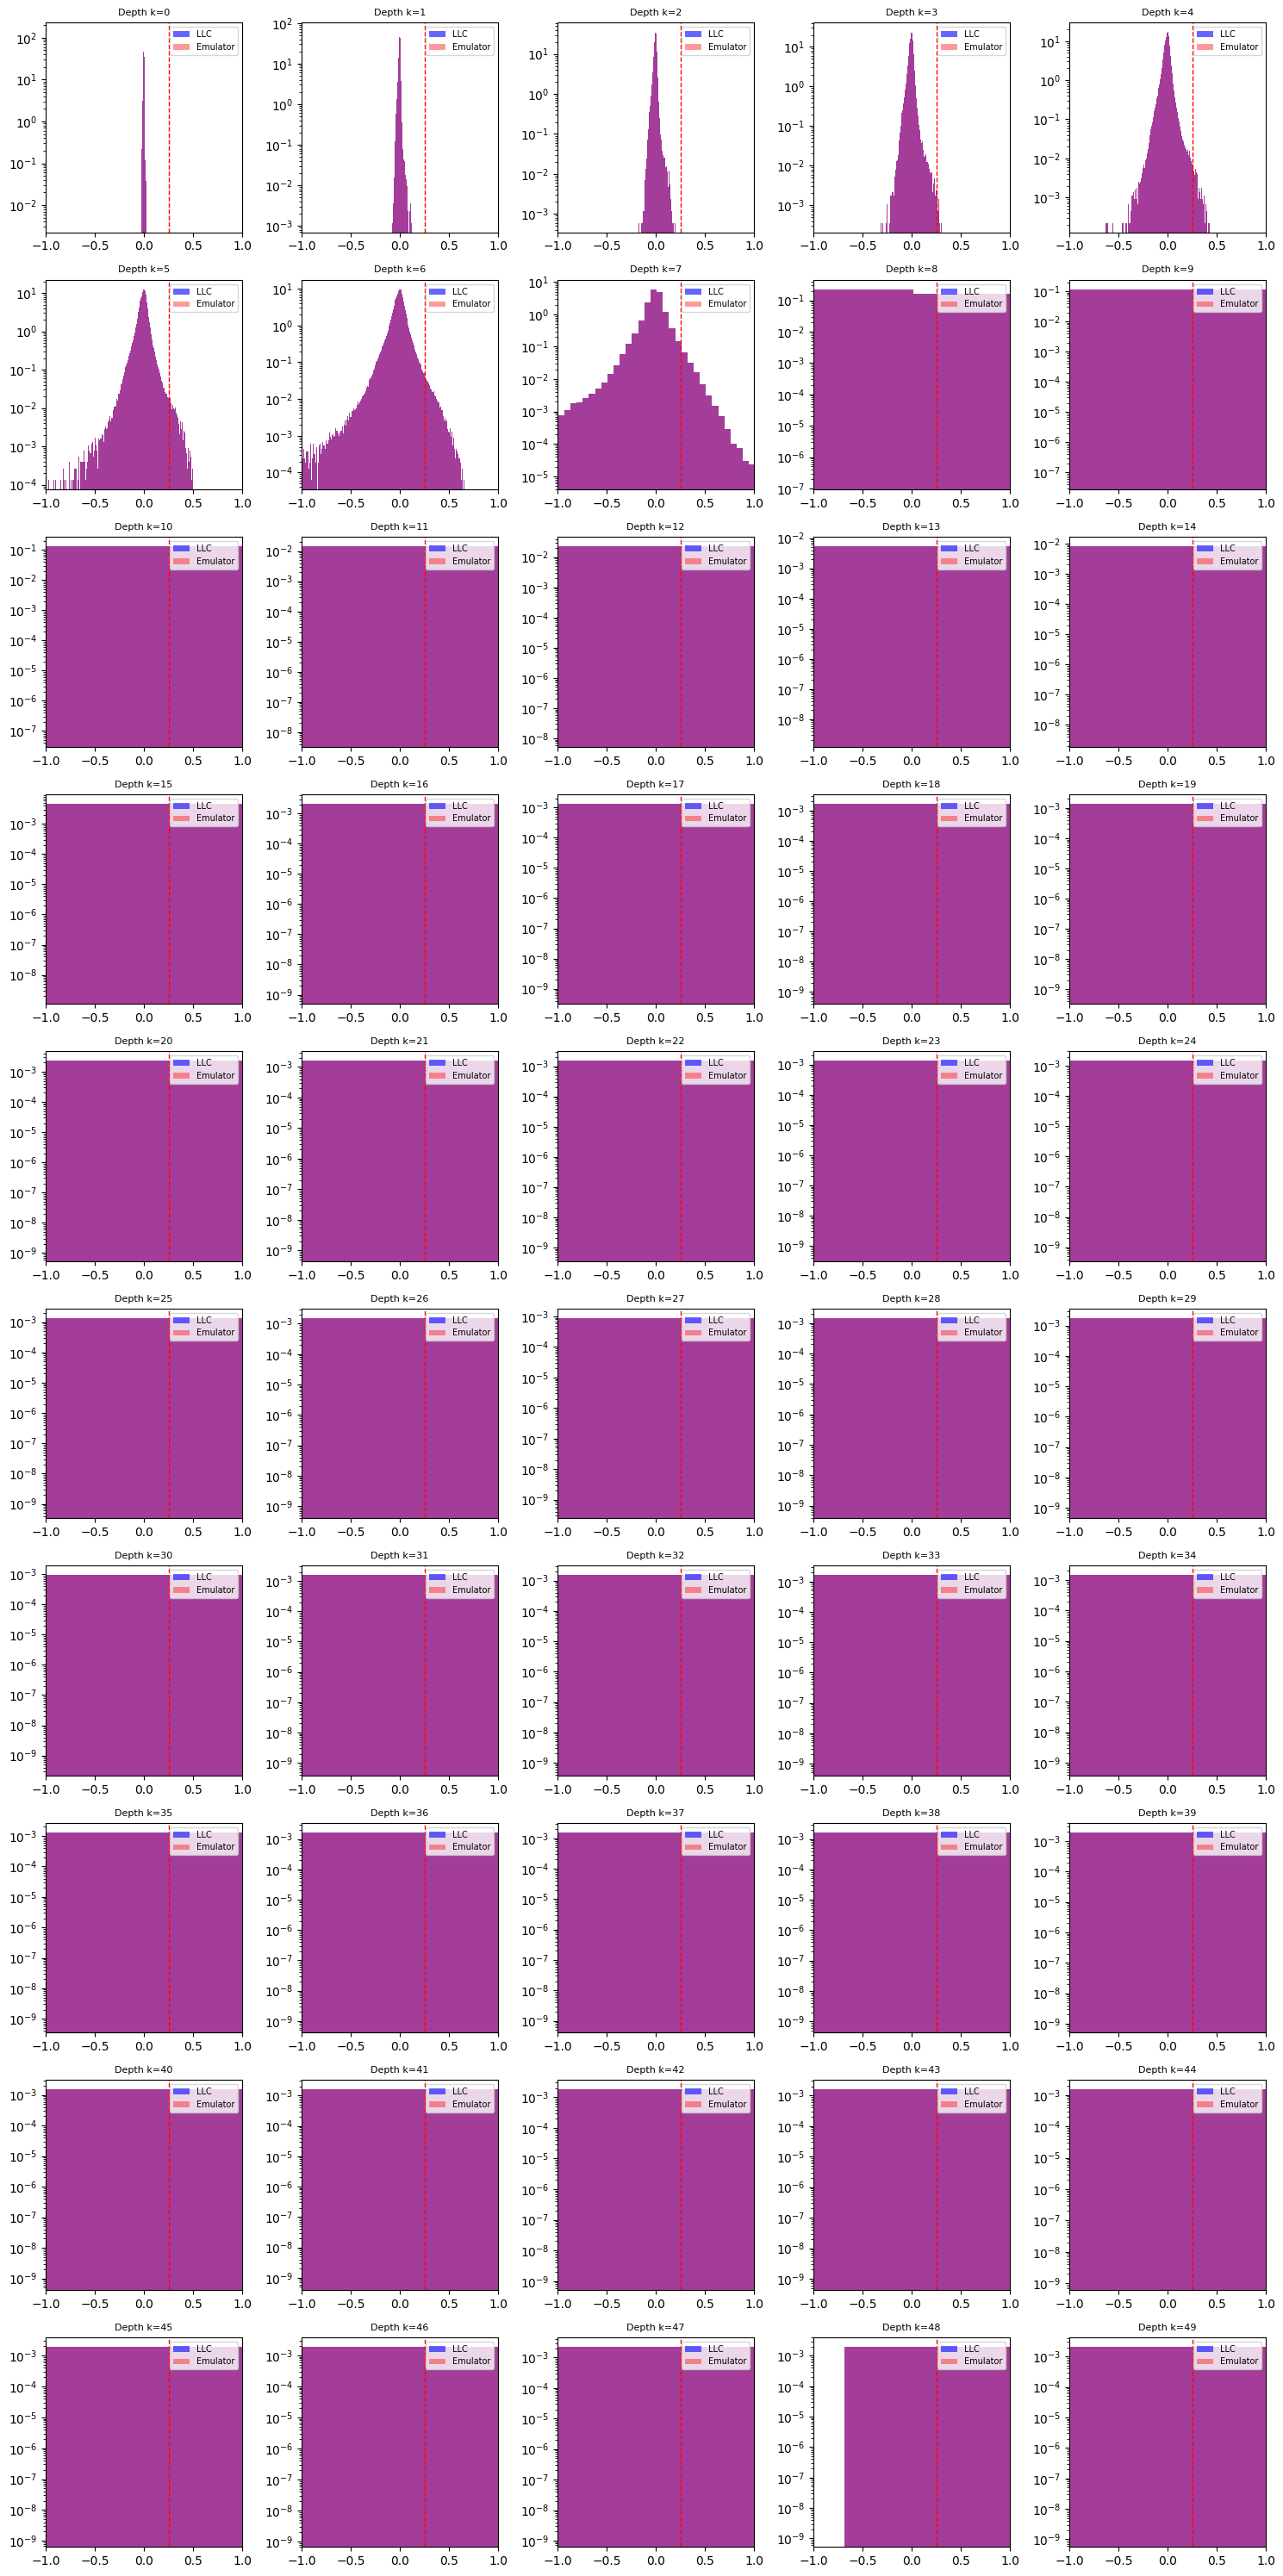

In [32]:
n_depths = len(Ri_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(Ri_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(Ri_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.set_yscale('log')
    ax.legend(fontsize=7)
    ax.axvline(x=0.25, color='red', linestyle='--', linewidth=1)
    ax.set_xlim(-1, 1)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

## T-S Plots